In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
customers = pd.read_csv("customers.csv")
loans = pd.read_csv("loans.csv")
applications = pd.read_csv("applications.csv")
transactions = pd.read_csv("transactions.csv")
defaults = pd.read_csv("defaults.csv")
branches = pd.read_csv("branches.csv")

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\3149424932.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv("applications.csv")


In [9]:
# applications

### 1. Data Quality and preparation

In [10]:
customers.head()

,Customer_ID,Full_Name,Contact_Number,Email,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID
0,C000001,Shayak Kumar,1549750578,saxenaindrans@gopal-krishnan.com,"27/062\nSangha Nagar, Bongaigaon 736150",53,Male,Single,Unemployed,886810,433,North,12 Years,RM0015
1,C000002,Divij Ghosh,2121540709,ramanindranil@tella.com,"H.No. 20, Edwin Circle\nKatihar 892167",62,Female,Single,Self-Employed,396746,418,West,10 Years,RM0276
2,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,736,Northeast,9 Years,RM0098
3,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,353,Central,11 Years,RM0231
4,C000005,Saanvi Chad,9281095585,arhaan11@master.net,"011, Kunda Marg\nHyderabad-505161",56,Male,Single,Self-Employed,1219355,735,West,1 Years,RM0107


In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  Account_Tenure           70000 non-null  object
 13  Relationship_Manager_ID  70000 non-null  object
dtypes: int64(4), object(10)
memory usage: 

In [12]:
loans.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668,Property
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012,Property
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347,NaN
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106,NaN
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127,NaN


In [13]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  object 
 1   Customer_ID           90000 non-null  object 
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  object 
 6   Repayment_Start_Date  90000 non-null  object 
 7   Repayment_End_Date    90000 non-null  object 
 8   Loan_Status           90000 non-null  object 
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    59806 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 8.2+ MB


In [14]:
applications.head()

,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved,NaN
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved,NaN
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved,NaN
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved,NaN
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved,NaN


In [15]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Application_ID    82600 non-null  object
 1   Loan_ID           70000 non-null  object
 2   Customer_ID       82600 non-null  object
 3   Application_Date  82600 non-null  object
 4   Approval_Date     70000 non-null  object
 5   Loan_Purpose      82600 non-null  object
 6   Source_Channel    82600 non-null  object
 7   Processing_Fee    82600 non-null  int64 
 8   Approval_Status   82600 non-null  object
 9   Rejection_Reason  12600 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.3+ MB


In [16]:
transactions.head()

,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


In [17]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Transaction_ID     495000 non-null  object
 1   Loan_ID            495000 non-null  object
 2   Customer_ID        495000 non-null  object
 3   Transaction_Date   495000 non-null  object
 4   Payment_Type       495000 non-null  object
 5   Amount             495000 non-null  int64 
 6   Overdue_Fee        495000 non-null  int64 
 7   Remaining_Balance  495000 non-null  int64 
 8   Mode_of_Payment    495000 non-null  object
dtypes: int64(3), object(6)
memory usage: 34.0+ MB


In [18]:
defaults.head()

,Default_ID,Loan_ID,Customer_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action
0,D000001,L007312,C007312,2022-07-20,94480,Job Loss,Full,30360,Yes
1,D000002,L028234,C028234,2023-09-23,10912,Job Loss,Partial,0,Yes
2,D000003,L008319,C008319,2024-08-04,73711,Other,NaN,9866,Yes
3,D000004,L046668,C046668,2021-10-16,48955,Other,NaN,0,Yes
4,D000005,L082934,C082934,2024-10-07,56952,Medical Emergency,NaN,0,No


In [19]:
defaults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Default_ID       9000 non-null   object
 1   Loan_ID          9000 non-null   object
 2   Customer_ID      9000 non-null   object
 3   Default_Date     9000 non-null   object
 4   Default_Amount   9000 non-null   int64 
 5   Default_Reason   9000 non-null   object
 6   Recovery_Status  6015 non-null   object
 7   Recovery_Amount  9000 non-null   int64 
 8   Legal_Action     9000 non-null   object
dtypes: int64(2), object(7)
memory usage: 632.9+ KB


In [20]:
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29
1,B002,Shan Group,East,4459,1201,149,96549019,8,35
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10


In [21]:
branches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name                 50 non-null     object
 2   Region                      50 non-null     object
 3   Total_Customers             50 non-null     int64 
 4   Total_Active_Loans          50 non-null     int64 
 5   Delinquent_Loans            50 non-null     int64 
 6   Loan_Disbursement_Amount    50 non-null     int64 
 7   Avg_Processing_Time         50 non-null     int64 
 8   Relationship_Manager_Count  50 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 3.6+ KB


#### Handling missing values

In [24]:
loans['Collateral_Details'].fillna("No collateral", inplace = True)

In [29]:
applications['Rejection_Reason'].fillna("No reason", inplace = True)
applications['Loan_ID'].fillna("Not Assigned", inplace=True)

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2404979984.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applications['Loan_ID'].fillna("Not Assigned", inplace=True)


In [30]:
defaults['Recovery_Status'].fillna("Not Recovered", inplace=True)

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\708988591.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  defaults['Recovery_Status'].fillna("Not Recovered", inplace=True)


#### Changing data types

In [32]:
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'])

In [33]:
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])
loans['Repayment_Start_Date'] = pd.to_datetime(loans['Repayment_Start_Date'])
loans['Repayment_End_Date'] = pd.to_datetime(loans['Repayment_End_Date'])

applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])

transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])

defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])

#### Repmoving duplicates

In [43]:
customers.drop_duplicates(inplace = True)
loans.drop_duplicates(inplace = True)
applications.drop_duplicates(inplace = True)
transactions.drop_duplicates(inplace = True)
defaults.drop_duplicates(inplace = True)
branches.drop_duplicates(inplace = True)



#### Data Types

In [48]:
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')
loans['Repayment_Start_Date'] = pd.to_datetime(loans['Repayment_Start_Date'], errors='coerce')
loans['Repayment_End_Date'] = pd.to_datetime(loans['Repayment_End_Date'], errors='coerce')

applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

#### Handling outliers

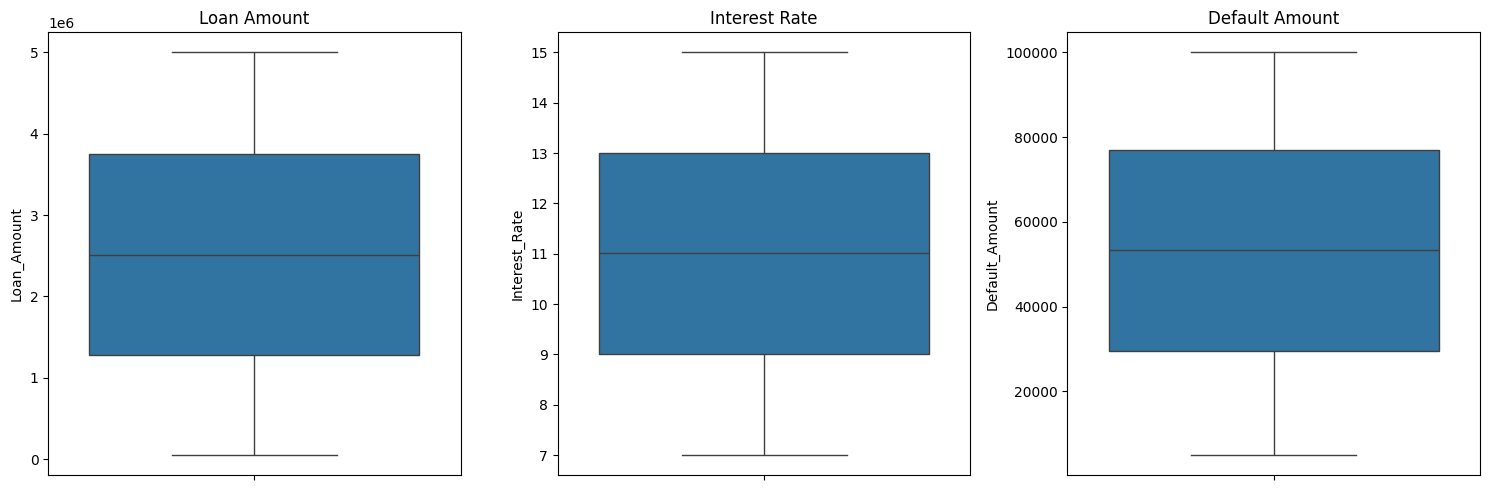

In [49]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=loans['Loan_Amount'])
plt.title("Loan Amount")

plt.subplot(1,3,2)
sns.boxplot(y=loans['Interest_Rate'])
plt.title("Interest Rate")

plt.subplot(1,3,3)
sns.boxplot(y=defaults['Default_Amount'])
plt.title("Default Amount")

plt.tight_layout()
plt.show()



In [50]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

loans = remove_outliers(loans, 'Loan_Amount')
loans = remove_outliers(loans, 'Interest_Rate')
defaults = remove_outliers(defaults, 'Default_Amount')

#### Distribution 

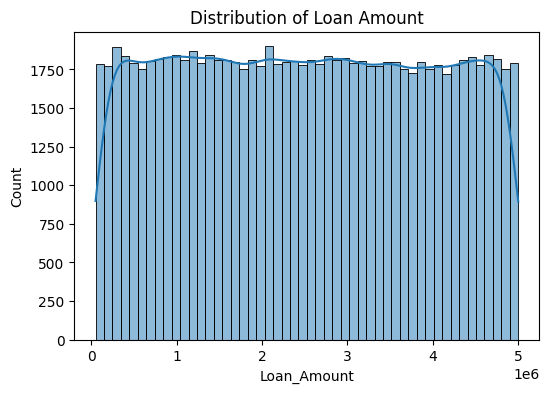

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(loans['Loan_Amount'], bins=50, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

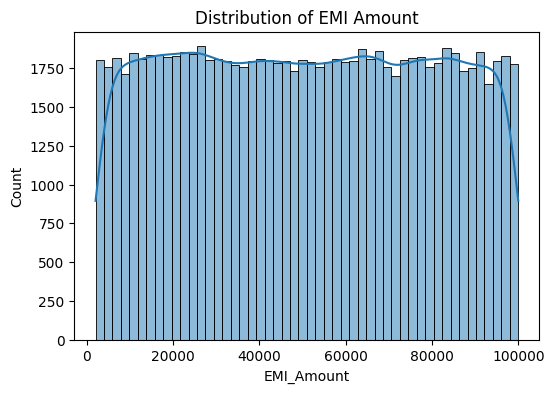

In [52]:
plt.figure(figsize=(6,4))
sns.histplot(loans['EMI_Amount'], bins=50, kde=True)
plt.title("Distribution of EMI Amount")
plt.show()

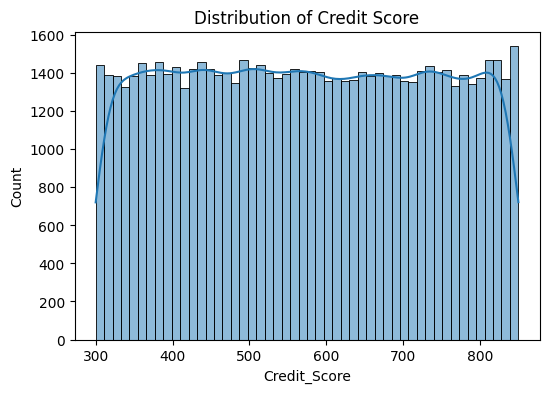

In [53]:
plt.figure(figsize=(6,4))
sns.histplot(customers['Credit_Score'], bins=50, kde=True)
plt.title("Distribution of Credit Score")
plt.show()

In [54]:
# Merge
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID')

# Merge defaults
loan_region['Default_Flag'] = loan_region['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

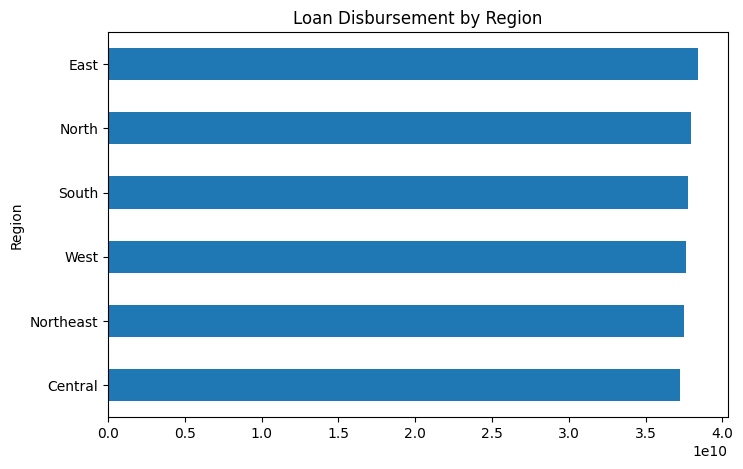

In [55]:
region_disbursement = loan_region.groupby('Region')['Loan_Amount'].sum().sort_values()

region_disbursement.plot(kind='barh', figsize=(8,5))
plt.title("Loan Disbursement by Region")
plt.show()

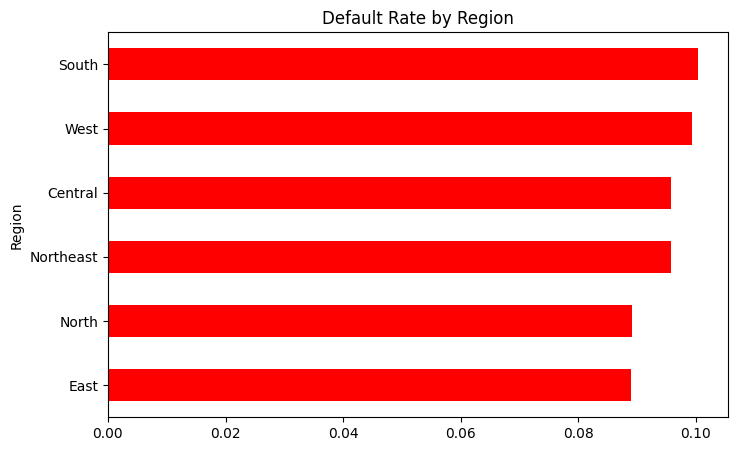

In [56]:
region_default = loan_region.groupby('Region')['Default_Flag'].mean().sort_values()

region_default.plot(kind='barh', figsize=(8,5), color='red')
plt.title("Default Rate by Region")
plt.show()

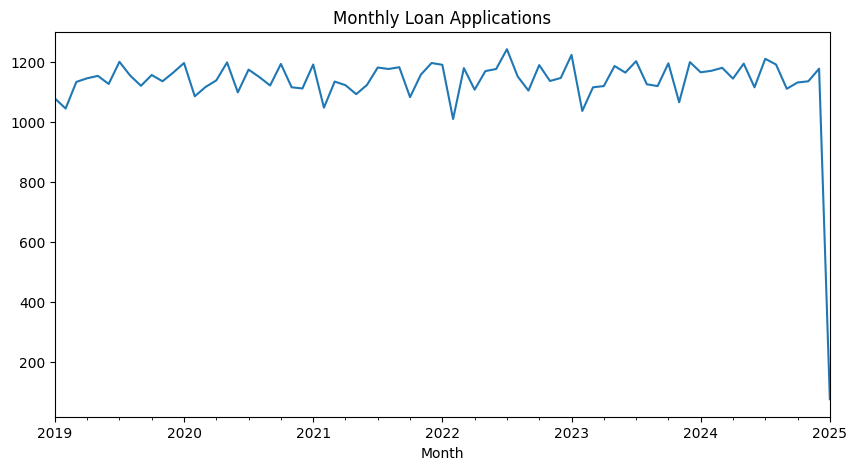

In [57]:
applications['Month'] = applications['Application_Date'].dt.to_period('M')

monthly_apps = applications.groupby('Month').size()

monthly_apps.plot(figsize=(10,5))
plt.title("Monthly Loan Applications")
plt.show()

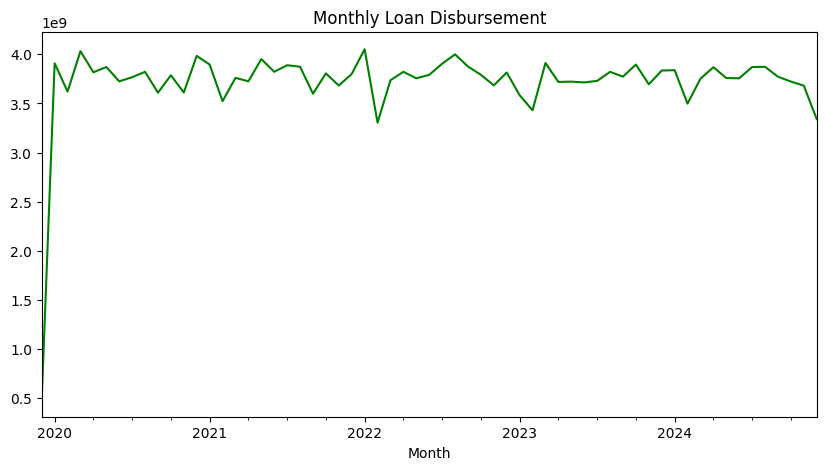

In [58]:
loans['Month'] = loans['Disbursal_Date'].dt.to_period('M')

monthly_disbursal = loans.groupby('Month')['Loan_Amount'].sum()

monthly_disbursal.plot(figsize=(10,5), color='green')
plt.title("Monthly Loan Disbursement")
plt.show()

#### Default risk analysis

In [60]:
df = loans.merge(customers, on='Customer_ID', how='left')
df['Default_Flag'] = df['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

In [61]:
corr_df = df[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']]

correlations = corr_df.corr()
print(correlations['Default_Flag'].sort_values(ascending=False))

Default_Flag     1.000000
Credit_Score    -0.001580
Loan_Amount     -0.003313
Interest_Rate   -0.003750
Name: Default_Flag, dtype: float64


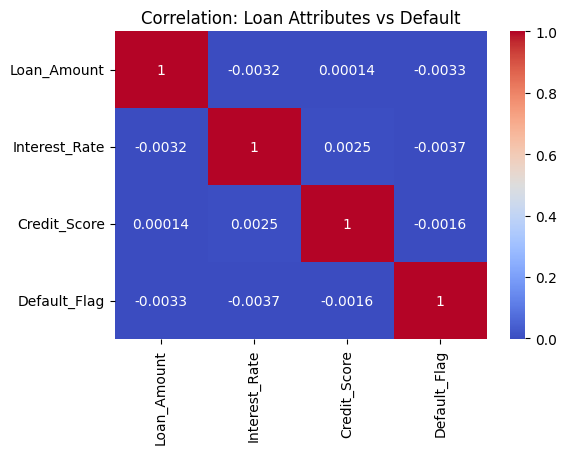

In [62]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Loan Attributes vs Default")
plt.show()

In [63]:
branch_df = branches.copy()
branch_df['Default_Rate'] = branch_df['Delinquent_Loans'] / branch_df['Total_Active_Loans']

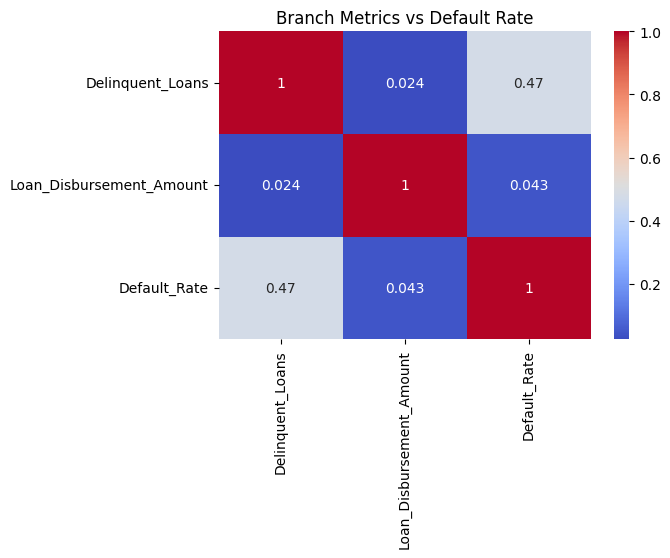

In [64]:
cols = ['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Default_Rate']

plt.figure(figsize=(6,4))
sns.heatmap(branch_df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Branch Metrics vs Default Rate")
plt.show()

#### Branch and regional performance

#### Rank branches

In [65]:
branch_ranking = branches.sort_values(by='Loan_Disbursement_Amount', ascending=False)
branch_ranking[['Branch_Name', 'Loan_Disbursement_Amount']]

,Branch_Name,Loan_Disbursement_Amount
35,Kara-Bahl,499562869
13,"Bhatti, Rau and Sem",482327541
11,Kaul Inc,465469874
47,Chawla-Subramanian,464419943
34,"Malhotra, Boase and Malhotra",449109596
42,Grover Group,447832443
2,Sachdev-Banerjee,445787808
49,Sani-Kale,442594434
9,Arya Ltd,435407779
36,Yogi Ltd,420746720


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2365189919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


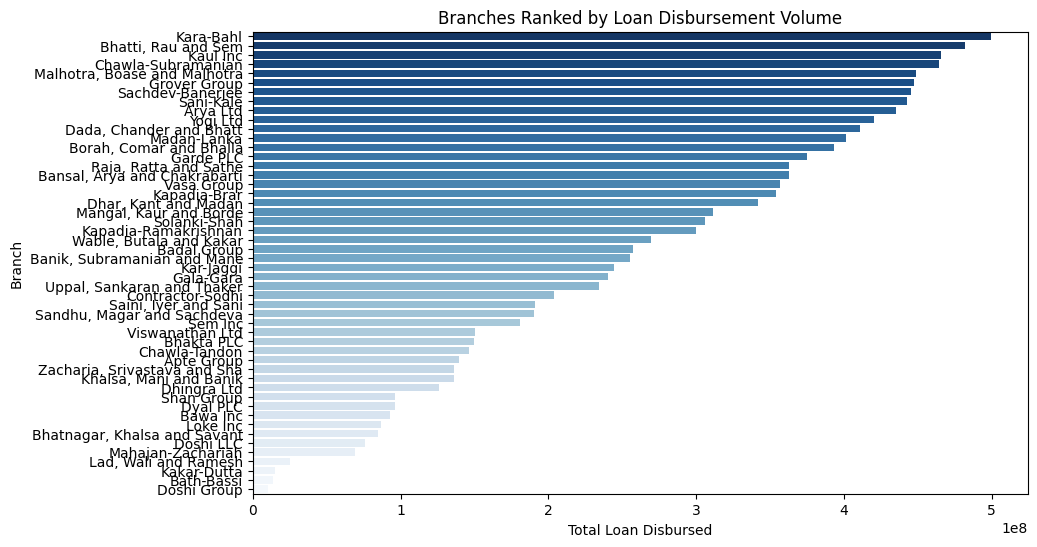

In [66]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Loan_Disbursement_Amount', 
    y='Branch_Name', 
    data=branch_ranking,
    palette='Blues_r'
)
plt.title("Branches Ranked by Loan Disbursement Volume")
plt.xlabel("Total Loan Disbursed")
plt.ylabel("Branch")
plt.show()

In [67]:

branch_ranking_time = branches.sort_values(by='Avg_Processing_Time')
branch_ranking_time[['Branch_Name', 'Avg_Processing_Time']]

,Branch_Name,Avg_Processing_Time
49,Sani-Kale,1
17,"Sandhu, Magar and Sachdeva",2
46,Chawla-Tandon,2
41,Kar-Jaggi,2
44,Solanki-Shah,3
11,Kaul Inc,3
26,Kapadia-Ramakrishnan,3
47,Chawla-Subramanian,4
32,"Saini, Iyer and Sani",5
22,"Wable, Butala and Kakar",5


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\198100429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


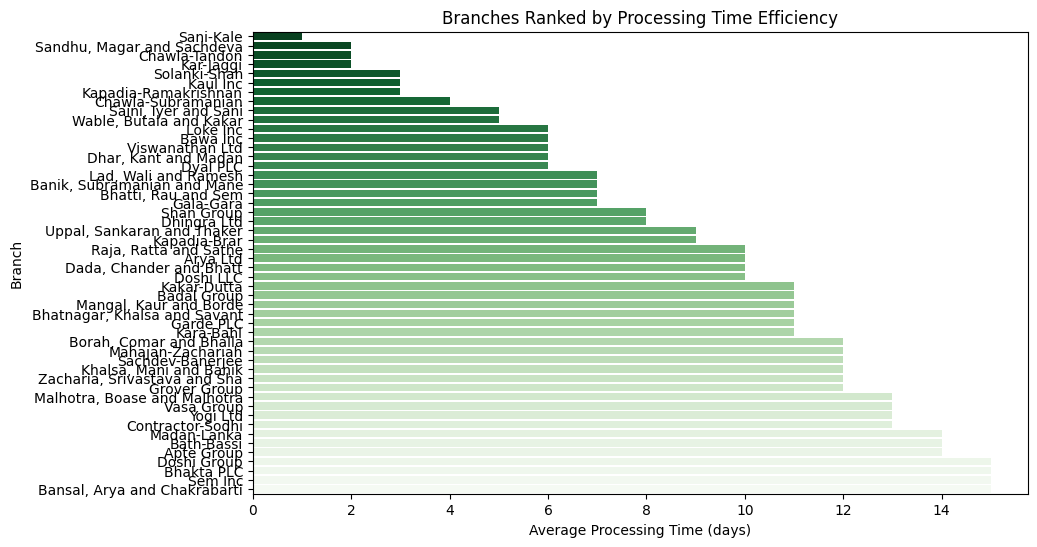

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Avg_Processing_Time', 
    y='Branch_Name', 
    data=branch_ranking_time,
    palette='Greens_r'
)
plt.title("Branches Ranked by Processing Time Efficiency")
plt.xlabel("Average Processing Time (days)")
plt.ylabel("Branch")
plt.show()

In [69]:
branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

branch_ranking_default = branches.sort_values(by='Default_Rate', ascending=False)
branch_ranking_default[['Branch_Name', 'Default_Rate']]

,Branch_Name,Default_Rate
2,Sachdev-Banerjee,1.377049
31,Mahajan-Zachariah,0.681275
7,Gala-Gara,0.513158
8,Vasa Group,0.449153
6,"Lad, Wali and Ramesh",0.427350
16,Doshi LLC,0.340741
41,Kar-Jaggi,0.335430
48,"Khalsa, Mani and Banik",0.328530
49,Sani-Kale,0.281734
43,Bawa Inc,0.269531


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\314889830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


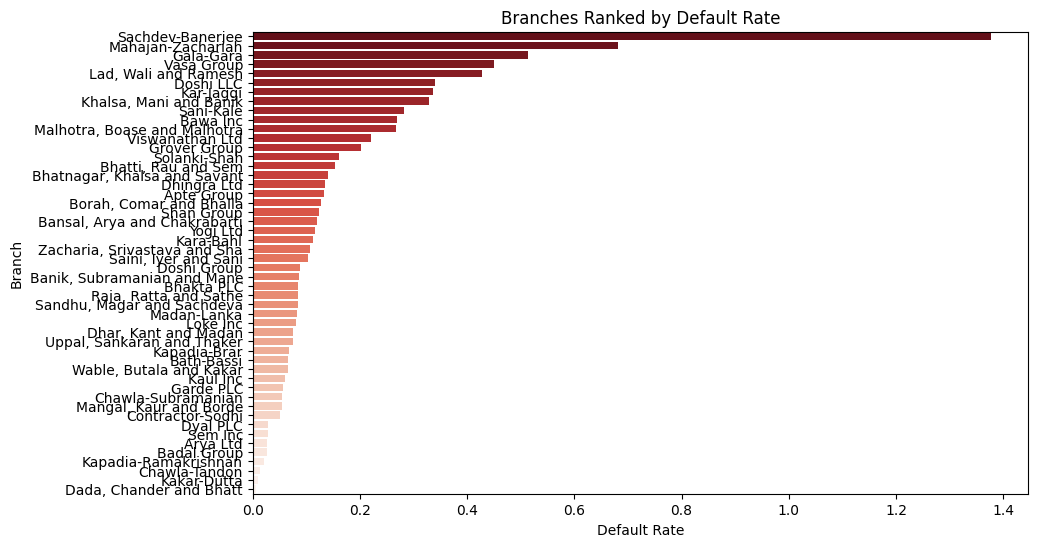

In [70]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Default_Rate', 
    y='Branch_Name', 
    data=branch_ranking_default,
    palette='Reds_r'
)
plt.title("Branches Ranked by Default Rate")
plt.xlabel("Default Rate")
plt.ylabel("Branch")
plt.show()

In [85]:
branch_recovery = branches.copy()
branch_recovery['Recovery_Rate'] = np.random.rand(len(branch_recovery))

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\497732846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


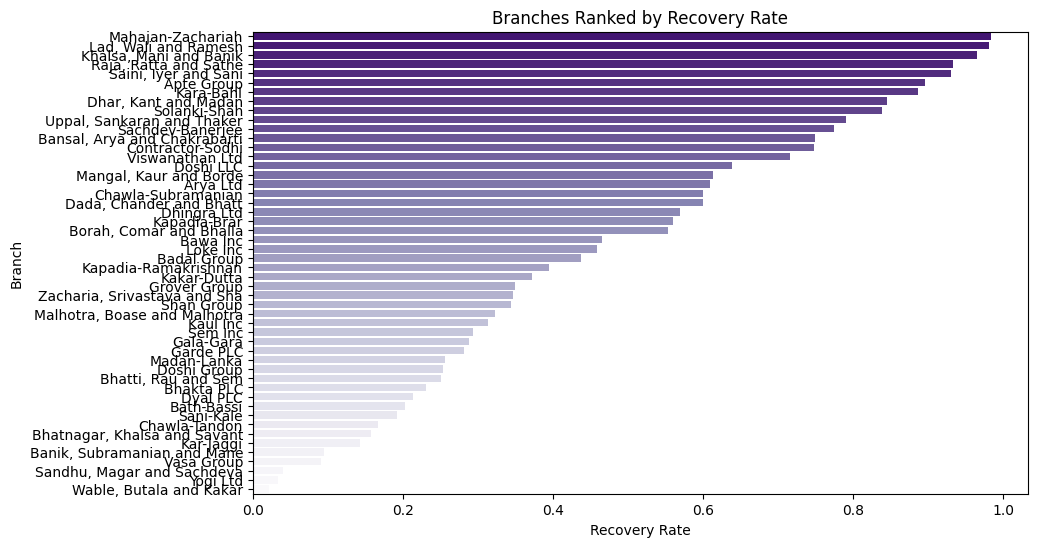

In [86]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Recovery_Rate', 
    y='Branch_Name', 
    data=branch_recovery.sort_values('Recovery_Rate', ascending=False),
    palette='Purples_r'
)
plt.title("Branches Ranked by Recovery Rate")
plt.xlabel("Recovery Rate")
plt.ylabel("Branch")
plt.show()

In [87]:

region_perf = branches.groupby('Region').agg({
    'Loan_Disbursement_Amount':'sum',
    'Avg_Processing_Time':'mean',
    'Default_Rate':'mean'
}).reset_index()

region_perf

,Region,Loan_Disbursement_Amount,Avg_Processing_Time,Default_Rate
0,Central,3316048302,9.500000,0.285097
1,East,2006676282,9.875000,0.098763
2,North,3296073904,10.357143,0.192330
3,Northeast,442827845,6.500000,0.218954
4,South,1694906506,9.000000,0.103170
5,West,1990828641,6.166667,0.095160


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\4199338782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Loan_Disbursement_Amount', data=region_perf, palette='Blues')


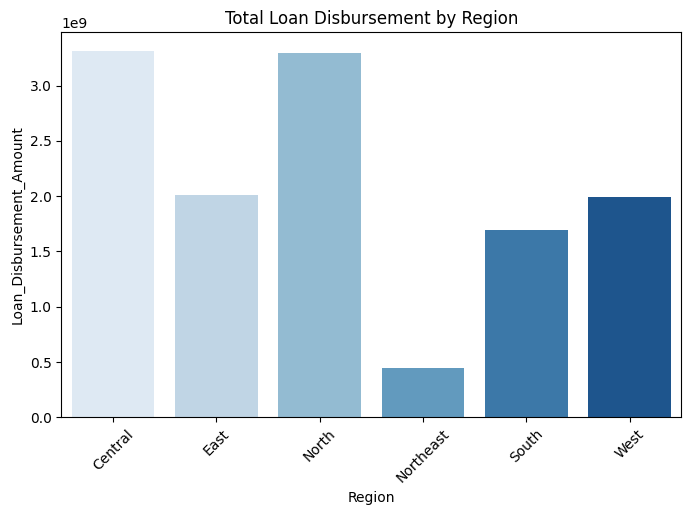

In [88]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Loan_Disbursement_Amount', data=region_perf, palette='Blues')
plt.title("Total Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1187838242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Default_Rate', data=region_perf, palette='Reds')


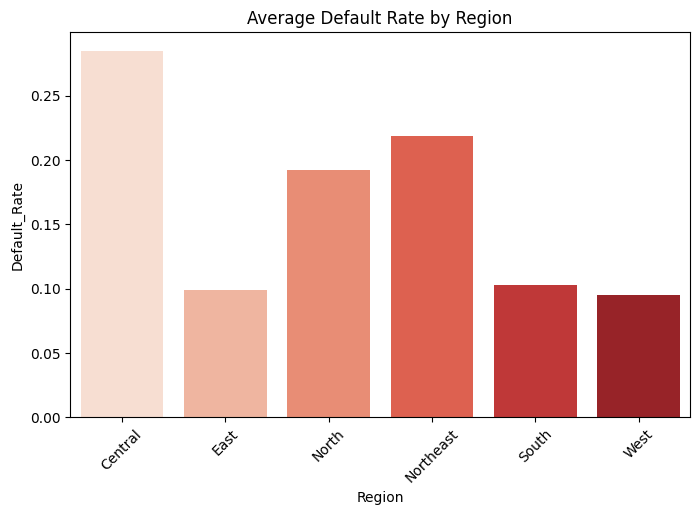

In [89]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Default_Rate', data=region_perf, palette='Reds')
plt.title("Average Default Rate by Region")
plt.xticks(rotation=45)
plt.show()

#### Customer Segmentation

In [90]:

def income_segment(income):
    if income < 300000:
        return 'Low Income'
    elif income < 700000:
        return 'Mid Income'
    else:
        return 'High Income'

customers['Income_Segment'] = customers['Annual_Income'].apply(income_segment)

# Count per segment
customers['Income_Segment'].value_counts()

Income_Segment
High Income    50521
Mid Income     15560
Low Income      3919
Name: count, dtype: int64

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1310486339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Income_Segment', data=customers, palette='Blues')


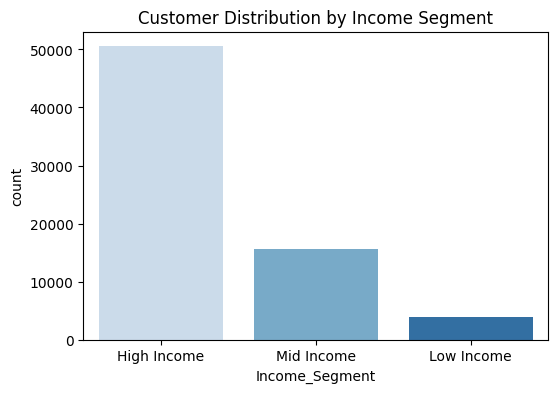

In [91]:
plt.figure(figsize=(6,4))
sns.countplot(x='Income_Segment', data=customers, palette='Blues')
plt.title("Customer Distribution by Income Segment")
plt.show()

In [92]:
def credit_segment(score):
    if score < 600:
        return 'Low Credit Score'
    elif score < 750:
        return 'Medium Credit Score'
    else:
        return 'High Credit Score'

customers['Credit_Segment'] = customers['Credit_Score'].apply(credit_segment)

# Count per segment
customers['Credit_Segment'].value_counts()

Credit_Segment
Low Credit Score       38335
Medium Credit Score    18852
High Credit Score      12813
Name: count, dtype: int64

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1242781464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Segment', data=customers, palette='Oranges')


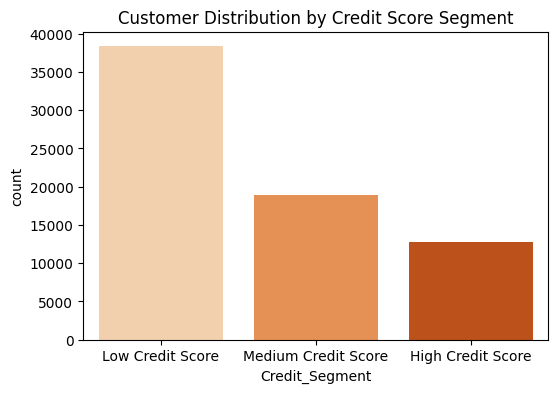

In [93]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Segment', data=customers, palette='Oranges')
plt.title("Customer Distribution by Credit Score Segment")
plt.show()

In [94]:
cust_loans = customers.merge(loans[['Customer_ID','Loan_Status','Loan_Amount','EMI_Amount','Overdue_Amount']], on='Customer_ID', how='left')

# Count per segment
loan_status_counts = cust_loans.groupby('Loan_Status')['Customer_ID'].count()
loan_status_counts

Loan_Status
Active     30050
Closed     30084
Overdue    29866
Name: Customer_ID, dtype: int64

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1035364984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=cust_loans, palette='Set2')


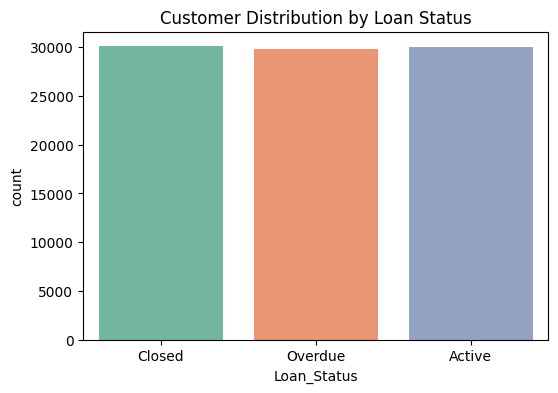

In [95]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=cust_loans, palette='Set2')
plt.title("Customer Distribution by Loan Status")
plt.show()

In [96]:
cust_loans['High_Risk_Flag'] = ((cust_loans['Credit_Score'] < 600) & (cust_loans['Overdue_Amount'] > 0)).astype(int)
cust_loans['High_Value_Flag'] = ((cust_loans['Annual_Income'] > 700000) & (cust_loans['Credit_Score'] >= 750) & (cust_loans['Loan_Status']=='Active')).astype(int)
cust_loans[['High_Risk_Flag','High_Value_Flag']].sum()

High_Risk_Flag     24674
High_Value_Flag     3993
dtype: int64

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\99128392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='High_Risk_Flag', data=cust_loans, palette='Reds')


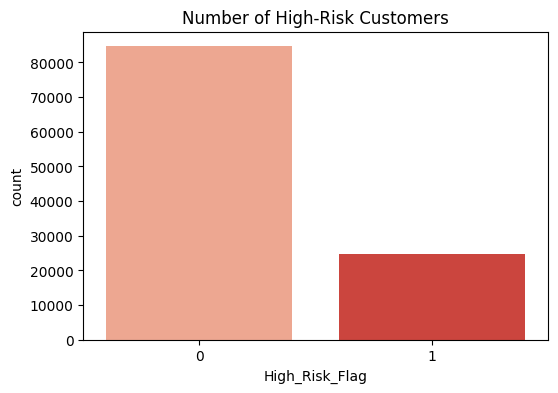

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\99128392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='High_Value_Flag', data=cust_loans, palette='Greens')


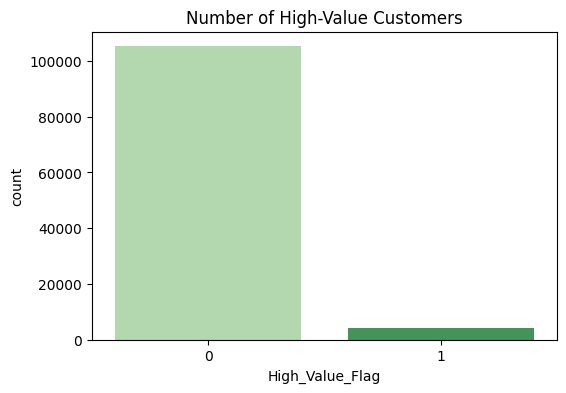

In [97]:
plt.figure(figsize=(6,4))
sns.countplot(x='High_Risk_Flag', data=cust_loans, palette='Reds')
plt.title("Number of High-Risk Customers")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='High_Value_Flag', data=cust_loans, palette='Greens')
plt.title("Number of High-Value Customers")
plt.show()

In [98]:
repay_behavior = cust_loans.groupby('Income_Segment')['Overdue_Amount'].mean().reset_index()
repay_behavior

,Income_Segment,Overdue_Amount
0,High Income,12756.018625
1,Low Income,12943.042231
2,Mid Income,12662.352487


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1118622585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_Segment', y='Overdue_Amount', data=repay_behavior, palette='coolwarm')


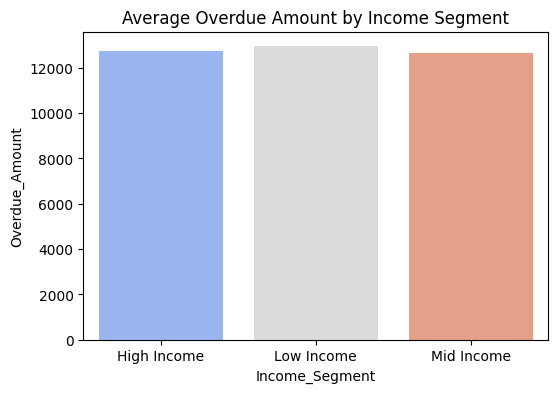

In [99]:
plt.figure(figsize=(6,4))
sns.barplot(x='Income_Segment', y='Overdue_Amount', data=repay_behavior, palette='coolwarm')
plt.title("Average Overdue Amount by Income Segment")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\3228527663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Credit_Segment', y='Overdue_Amount', data=repay_behavior_credit, palette='magma')


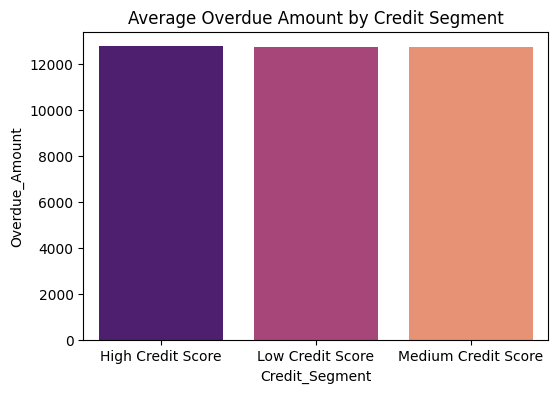

In [100]:
# Average Overdue Amount by Credit Segment
repay_behavior_credit = cust_loans.groupby('Credit_Segment')['Overdue_Amount'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='Credit_Segment', y='Overdue_Amount', data=repay_behavior_credit, palette='magma')
plt.title("Average Overdue Amount by Credit Segment")
plt.show()

#### advanced statistical analysis

In [101]:
df_stats = loans.merge(customers[['Customer_ID','Credit_Score']], on='Customer_ID', how='left')
df_stats['Default_Flag'] = df_stats['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

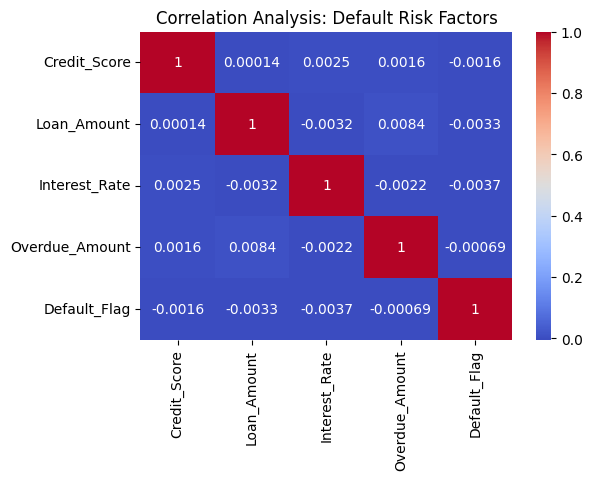

In [102]:
cols_default = ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Flag']

corr_default = df_stats[cols_default].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_default, annot=True, cmap='coolwarm')
plt.title("Correlation Analysis: Default Risk Factors")
plt.show()

In [103]:
df_pairwise = loans.merge(defaults[['Loan_ID','Default_Amount','Recovery_Amount']], on='Loan_ID', how='left')
df_pairwise['Recovery_Rate'] = df_pairwise['Recovery_Amount'] / df_pairwise['Default_Amount']

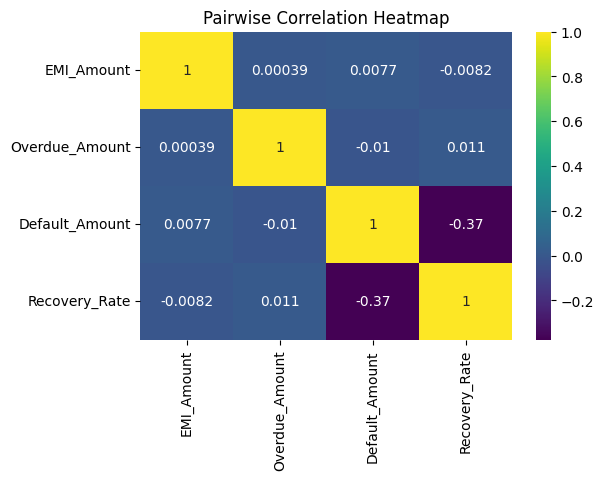

In [104]:
cols_pairwise = ['EMI_Amount', 'Overdue_Amount', 'Default_Amount', 'Recovery_Rate']

plt.figure(figsize=(6,4))
sns.heatmap(df_pairwise[cols_pairwise].corr(), annot=True, cmap='viridis')
plt.title("Pairwise Correlation Heatmap")
plt.show()

In [105]:
branch_corr = branches.copy()
branch_corr['Recovery_Rate'] = np.random.rand(len(branch_corr))*0.9  # Replace with real mapping if available

#### Transaction and Recovery Analysis

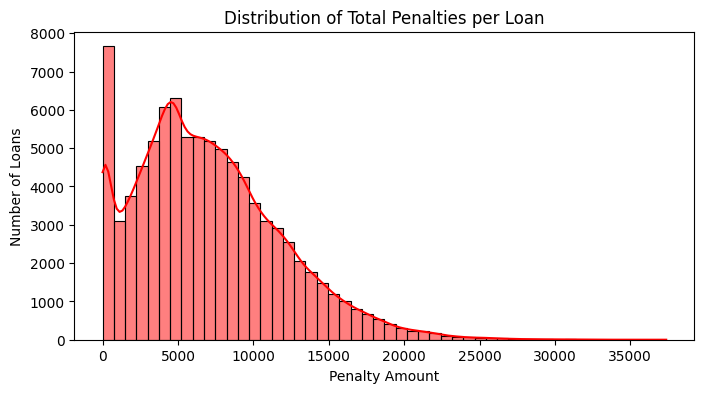

In [106]:

total_penalty = transactions['Overdue_Fee'].sum()
total_penalty

penalty_per_loan = transactions.groupby('Loan_ID')['Overdue_Fee'].sum().reset_index()

plt.figure(figsize=(8,4))
sns.histplot(penalty_per_loan['Overdue_Fee'], bins=50, kde=True, color='red')
plt.title("Distribution of Total Penalties per Loan")
plt.xlabel("Penalty Amount")
plt.ylabel("Number of Loans")
plt.show()

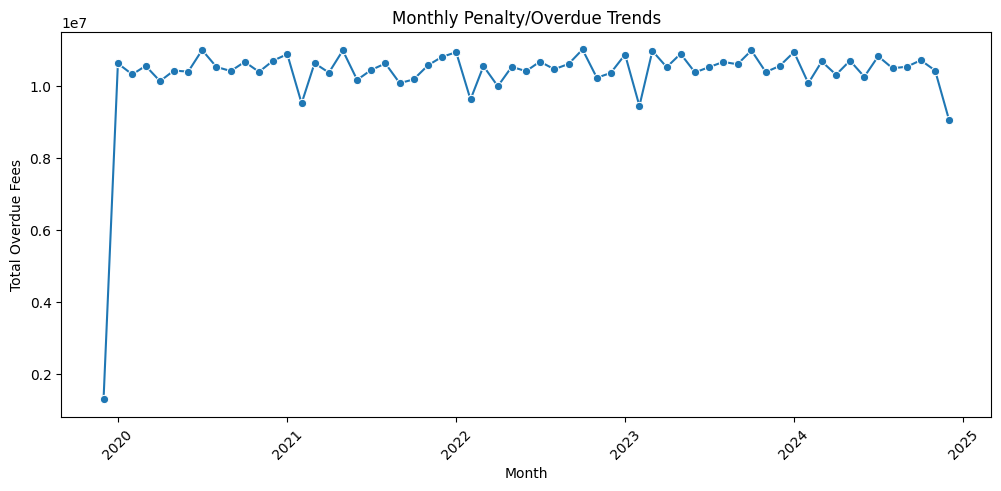

In [107]:

transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])
transactions['Month'] = transactions['Transaction_Date'].dt.to_period('M')
monthly_overdue = transactions.groupby('Month')['Overdue_Fee'].sum().reset_index()
monthly_overdue['Month'] = monthly_overdue['Month'].dt.to_timestamp()

plt.figure(figsize=(12,5))
sns.lineplot(x='Month', y='Overdue_Fee', data=monthly_overdue, marker='o')
plt.title("Monthly Penalty/Overdue Trends")
plt.xlabel("Month")
plt.ylabel("Total Overdue Fees")
plt.xticks(rotation=45)
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\4123743544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery_Rate', y='Default_Reason', data=recovery_reason.sort_values('Recovery_Rate', ascending=False), palette='viridis')


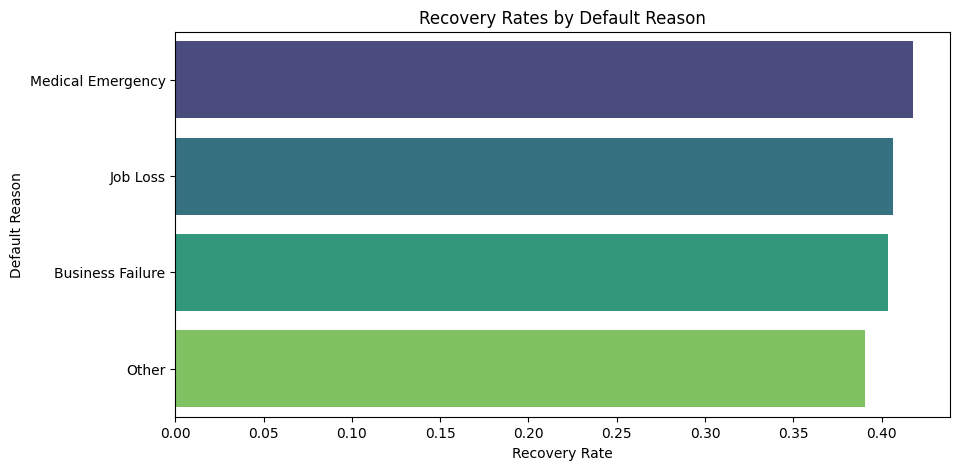

In [108]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

recovery_reason = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='Recovery_Rate', y='Default_Reason', data=recovery_reason.sort_values('Recovery_Rate', ascending=False), palette='viridis')
plt.title("Recovery Rates by Default Reason")
plt.xlabel("Recovery Rate")
plt.ylabel("Default Reason")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\502476158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')


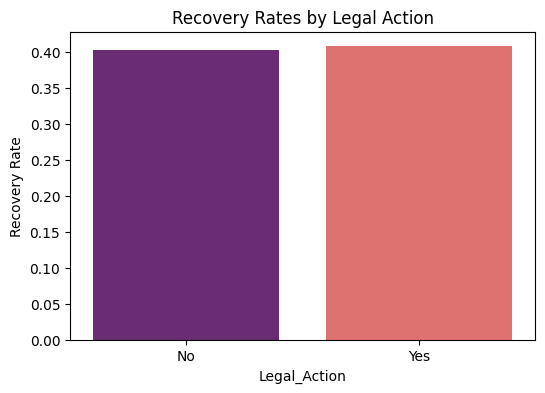

In [109]:

recovery_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')
plt.title("Recovery Rates by Legal Action")
plt.ylabel("Recovery Rate")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2680752613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Recovery_Rate', data=recovery_region, palette='coolwarm')


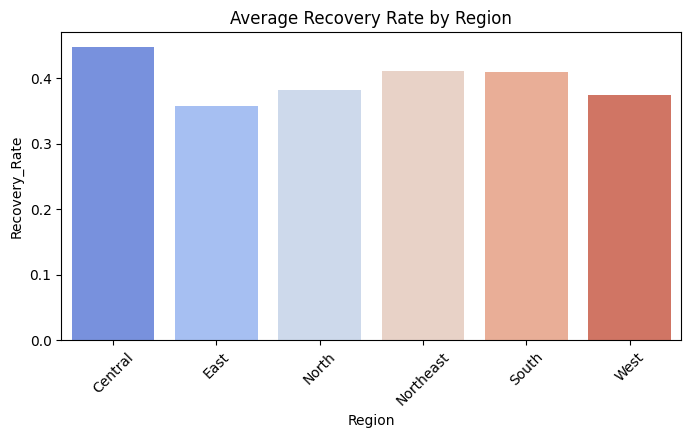

In [110]:

defaults_region = defaults.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
recovery_region = defaults_region.groupby('Region')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(x='Region', y='Recovery_Rate', data=recovery_region, palette='coolwarm')
plt.title("Average Recovery Rate by Region")
plt.xticks(rotation=45)
plt.show()

In [112]:

if 'Branch_ID' in loans.columns:
    defaults_branch = defaults.merge(loans[['Loan_ID','Branch_ID']], on='Loan_ID', how='left')
    defaults_branch = defaults_branch.merge(branches[['Branch_ID','Branch_Name']], on='Branch_ID', how='left')
    recovery_branch = defaults_branch.groupby('Branch_Name')['Recovery_Rate'].mean().reset_index()
    plt.figure(figsize=(10,5))
    sns.barplot(x='Recovery_Rate', y='Branch_Name', data=recovery_branch.sort_values('Recovery_Rate', ascending=False), palette='Purples')
    plt.title("Average Recovery Rate by Branch")
    plt.xlabel("Recovery Rate")
    plt.ylabel("Branch")
    plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1346066961.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery_Rate', y='Branch_Name', data=recovery_branch.sort_values('Recovery_Rate', ascending=False), palette='Purples')


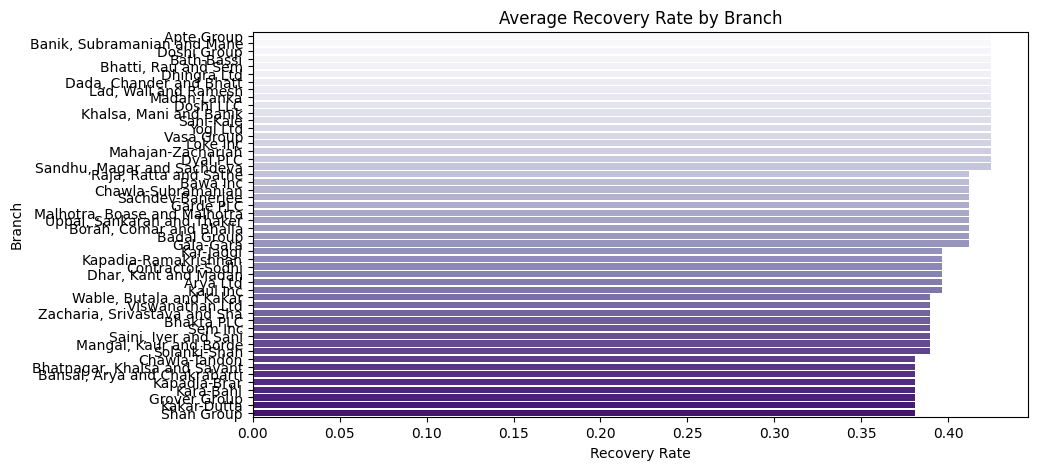

In [114]:

loan_branch = loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')

loan_branch = loan_branch.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')

defaults_branch = defaults.merge(loan_branch[['Loan_ID','Branch_ID','Branch_Name']], on='Loan_ID', how='left')

recovery_branch = defaults_branch.groupby('Branch_Name')['Recovery_Rate'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Recovery_Rate', y='Branch_Name', data=recovery_branch.sort_values('Recovery_Rate', ascending=False), palette='Purples')
plt.title("Average Recovery Rate by Branch")
plt.xlabel("Recovery Rate")
plt.ylabel("Branch")
plt.show()

#### EMI Analysis

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\167621747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery_Rate', y='Default_Reason', data=recovery_reason.sort_values('Recovery_Rate', ascending=False), palette='viridis')


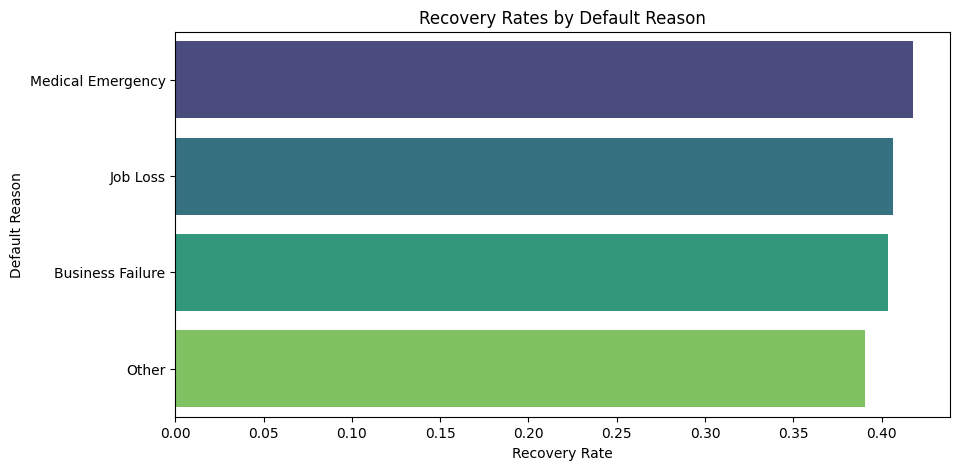

In [115]:
recovery_reason = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='Recovery_Rate', y='Default_Reason', data=recovery_reason.sort_values('Recovery_Rate', ascending=False), palette='viridis')
plt.title("Recovery Rates by Default Reason")
plt.xlabel("Recovery Rate")
plt.ylabel("Default Reason")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\502476158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')


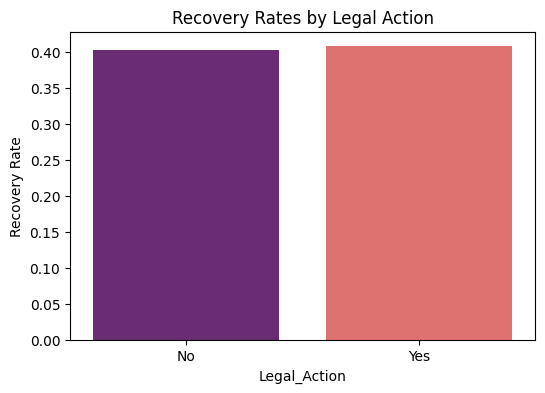

In [116]:

recovery_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')
plt.title("Recovery Rates by Legal Action")
plt.ylabel("Recovery Rate")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\3636302182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')


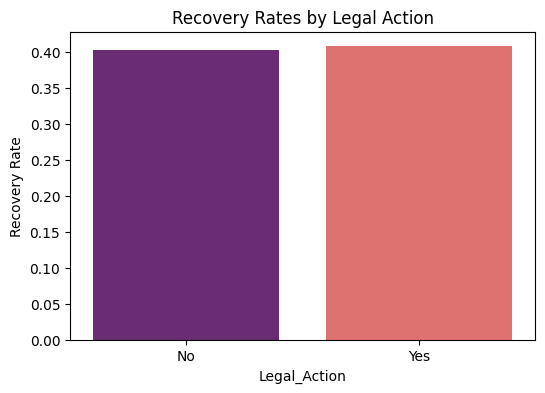

In [117]:
recovery_legal = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal, palette='magma')
plt.title("Recovery Rates by Legal Action")
plt.ylabel("Recovery Rate")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\4127916672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery_Rate', y='Branch_Name', data=recovery_branch.sort_values('Recovery_Rate', ascending=False), palette='Purples')


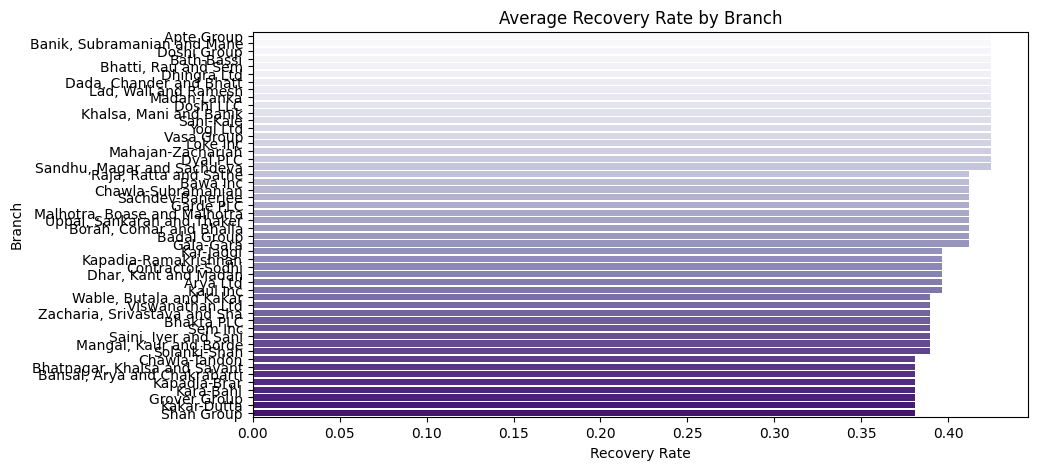

In [118]:
loan_branch = loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
loan_branch = loan_branch.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')
defaults_branch = defaults.merge(loan_branch[['Loan_ID','Branch_ID','Branch_Name']], on='Loan_ID', how='left')
recovery_branch = defaults_branch.groupby('Branch_Name')['Recovery_Rate'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='Recovery_Rate', y='Branch_Name', data=recovery_branch.sort_values('Recovery_Rate', ascending=False), palette='Purples')
plt.title("Average Recovery Rate by Branch")
plt.xlabel("Recovery Rate")
plt.ylabel("Branch")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\514865750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default_Flag', y='EMI_Amount', data=loans, palette='Set2')


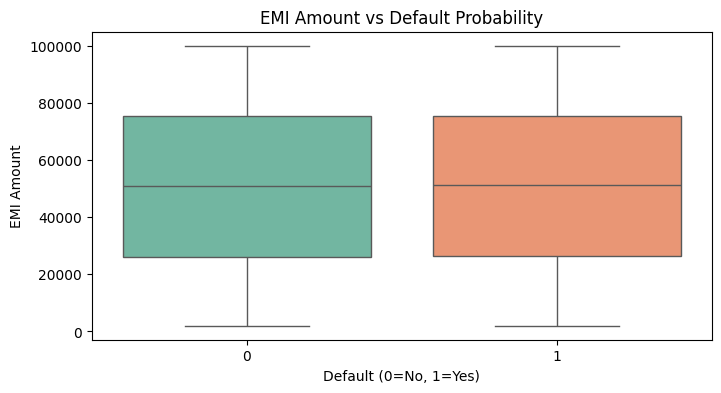

In [119]:
loans['Default_Flag'] = loans['Loan_ID'].isin(defaults['Loan_ID']).astype(int)
plt.figure(figsize=(8,4))
sns.boxplot(x='Default_Flag', y='EMI_Amount', data=loans, palette='Set2')
plt.title("EMI Amount vs Default Probability")
plt.xlabel("Default (0=No, 1=Yes)")
plt.ylabel("EMI Amount")
plt.show()

#### Loan application insights

In [121]:
approval_counts = applications['Approval_Status'].value_counts(normalize=True) * 100
approval_counts

Approval_Status
Approved    84.745763
Rejected    15.254237
Name: proportion, dtype: float64

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\56556859.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Rejection_Reason', data=rejection_reasons, palette='Reds')


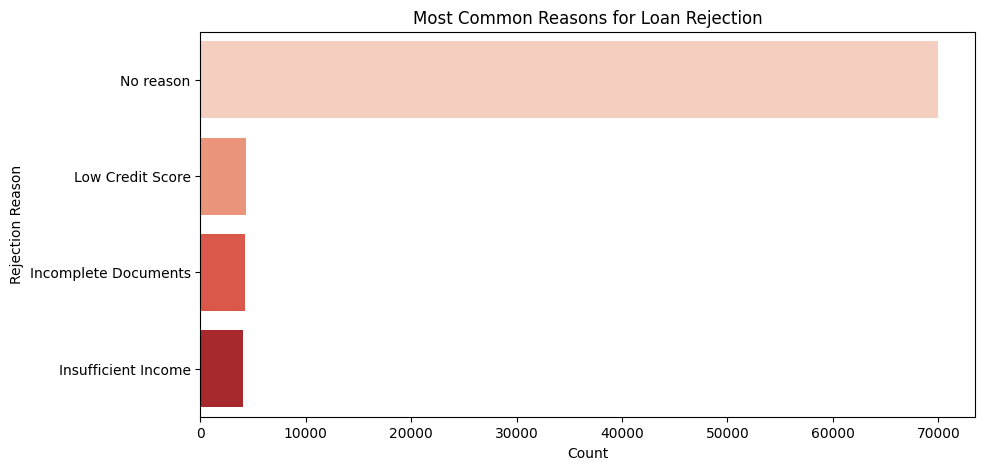

In [123]:
rejection_reasons = applications['Rejection_Reason'].value_counts().reset_index()
rejection_reasons.columns = ['Rejection_Reason', 'Count']

plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Rejection_Reason', data=rejection_reasons, palette='Reds')
plt.title("Most Common Reasons for Loan Rejection")
plt.xlabel("Count")
plt.ylabel("Rejection Reason")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2052304738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Approval_Status', y='Processing_Fee', data=applications, palette='Set2')


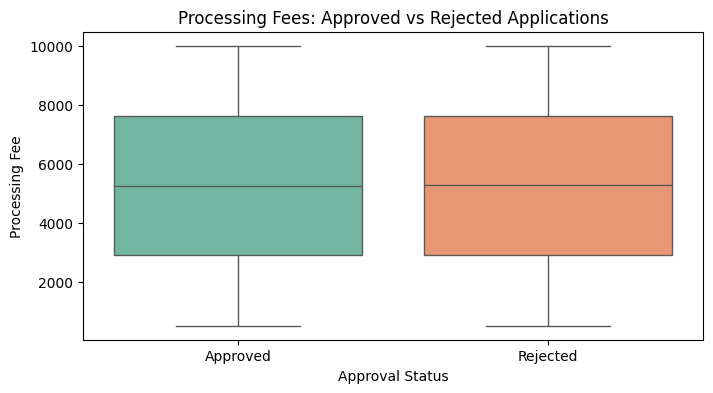

In [124]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Approval_Status', y='Processing_Fee', data=applications, palette='Set2')
plt.title("Processing Fees: Approved vs Rejected Applications")
plt.xlabel("Approval Status")
plt.ylabel("Processing Fee")
plt.show()

#### 10. Recovery Effectiveness 

In [126]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']
defaults[['Default_ID','Recovery_Rate']].head()

,Default_ID,Recovery_Rate
0,D000001,0.321338
1,D000002,0.000000
2,D000003,0.133847
3,D000004,0.000000
4,D000005,0.000000


C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\16729294.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal_action, palette='magma')


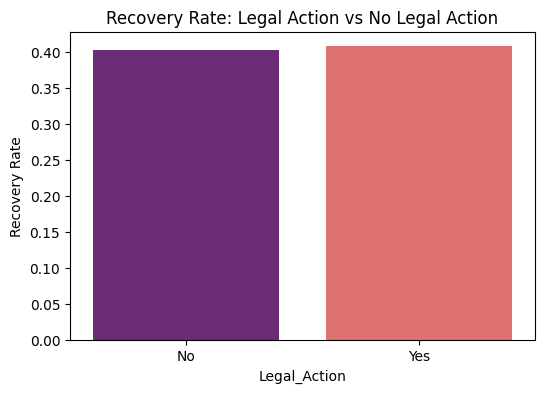

In [128]:
recovery_legal_action = defaults.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='Legal_Action', y='Recovery_Rate', data=recovery_legal_action, palette='magma')
plt.title("Recovery Rate: Legal Action vs No Legal Action")
plt.ylabel("Recovery Rate")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2334756132.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery_Rate', y='Branch_Name', data=branch_recovery.sort_values('Recovery_Rate', ascending=False), palette='Purples')


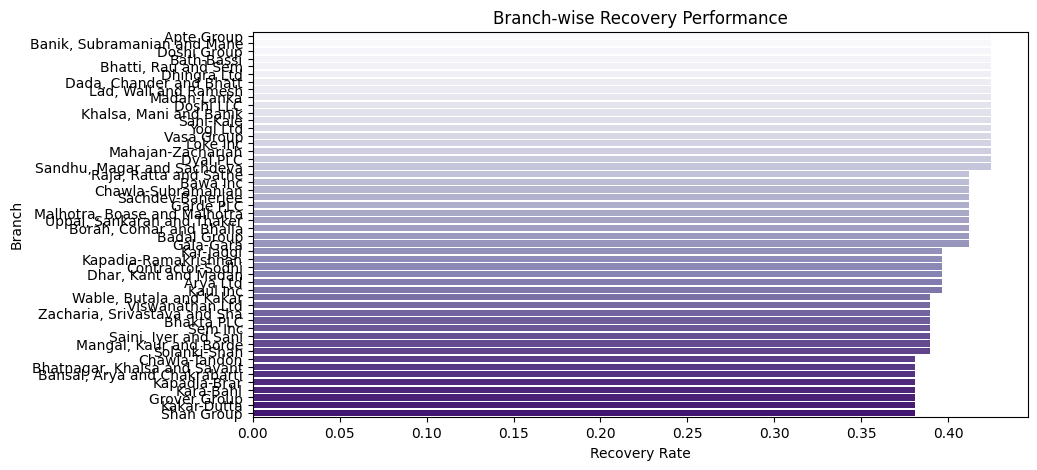

In [129]:
loan_branch = loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
loan_branch = loan_branch.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')
defaults_branch = defaults.merge(loan_branch[['Loan_ID','Branch_ID','Branch_Name']], on='Loan_ID', how='left')

branch_recovery = defaults_branch.groupby('Branch_Name')['Recovery_Rate'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Recovery_Rate', y='Branch_Name', data=branch_recovery.sort_values('Recovery_Rate', ascending=False), palette='Purples')
plt.title("Branch-wise Recovery Performance")
plt.xlabel("Recovery Rate")
plt.ylabel("Branch")
plt.show()

#### 11. Loan Disbursement Efficiency

In [136]:
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'])

applications['Processing_Time_Days'] = (applications['Approval_Date'] - applications['Application_Date']).dt.days

applications['Processing_Time_Days'].describe()

count    70000.000000
mean       175.396157
std        823.908827
min      -1826.000000
25%       -419.000000
50%        177.000000
75%        766.000000
max       2181.000000
Name: Processing_Time_Days, dtype: float64

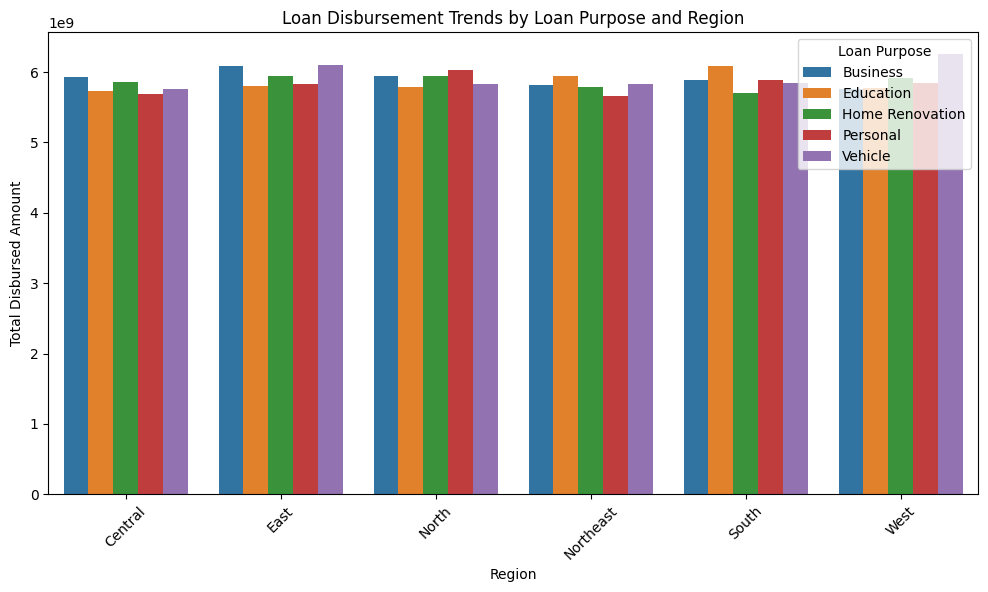

In [138]:
# Disbursement trends by Loan Purpose and Region
loan_app = loans.merge(applications[['Loan_ID','Loan_Purpose']], on='Loan_ID', how='left')
loan_app = loan_app.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')

disbursement_region = loan_app.groupby(['Region','Loan_Purpose'])['Loan_Amount'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Loan_Amount', hue='Loan_Purpose', data=disbursement_region)
plt.title("Loan Disbursement Trends by Loan Purpose and Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursed Amount")
plt.xticks(rotation=45)
plt.legend(title='Loan Purpose')
plt.show()

#### 12. Profitability analysis

In [139]:
# Calculate total interest income generated across all loans
# Interest Income = Loan_Amount * Interest_Rate * (Loan_Term / 12) / 100
loans['Interest_Income'] = loans['Loan_Amount'] * loans['Interest_Rate'] * (loans['Loan_Term'] / 12) / 100

total_interest_income = loans['Interest_Income'].sum()
total_interest_income

np.float64(75037526934.92252)

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\3205763285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Interest_Income', y='Loan_Purpose', data=profit_by_purpose.sort_values('Interest_Income', ascending=False), palette='Greens')


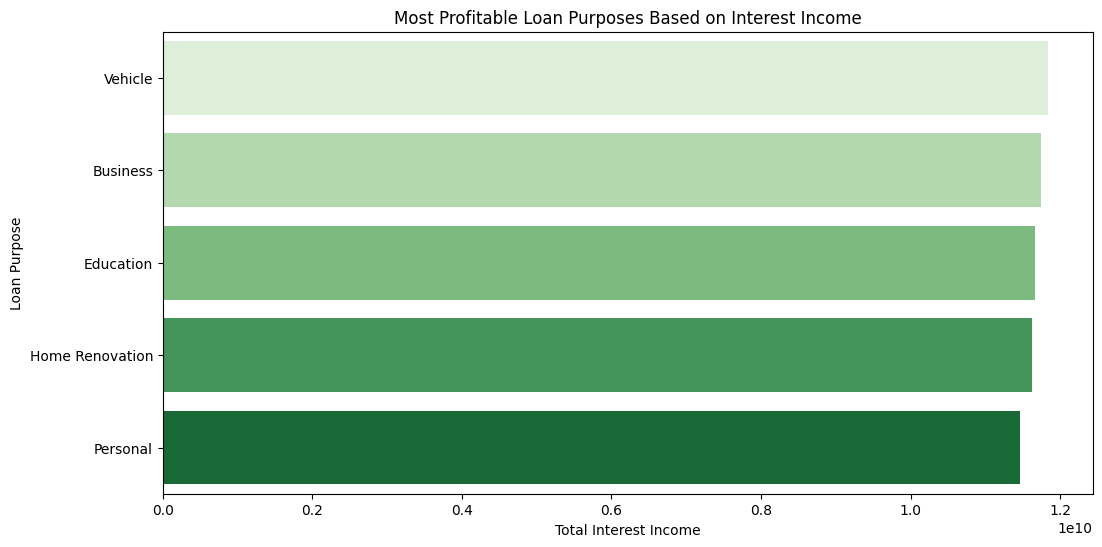

In [140]:
# Identify most profitable loan purposes based on interest earnings
loan_app_interest = loans.merge(applications[['Loan_ID','Loan_Purpose']], on='Loan_ID', how='left')
profit_by_purpose = loan_app_interest.groupby('Loan_Purpose')['Interest_Income'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Interest_Income', y='Loan_Purpose', data=profit_by_purpose.sort_values('Interest_Income', ascending=False), palette='Greens')
plt.title("Most Profitable Loan Purposes Based on Interest Income")
plt.xlabel("Total Interest Income")
plt.ylabel("Loan Purpose")
plt.show()

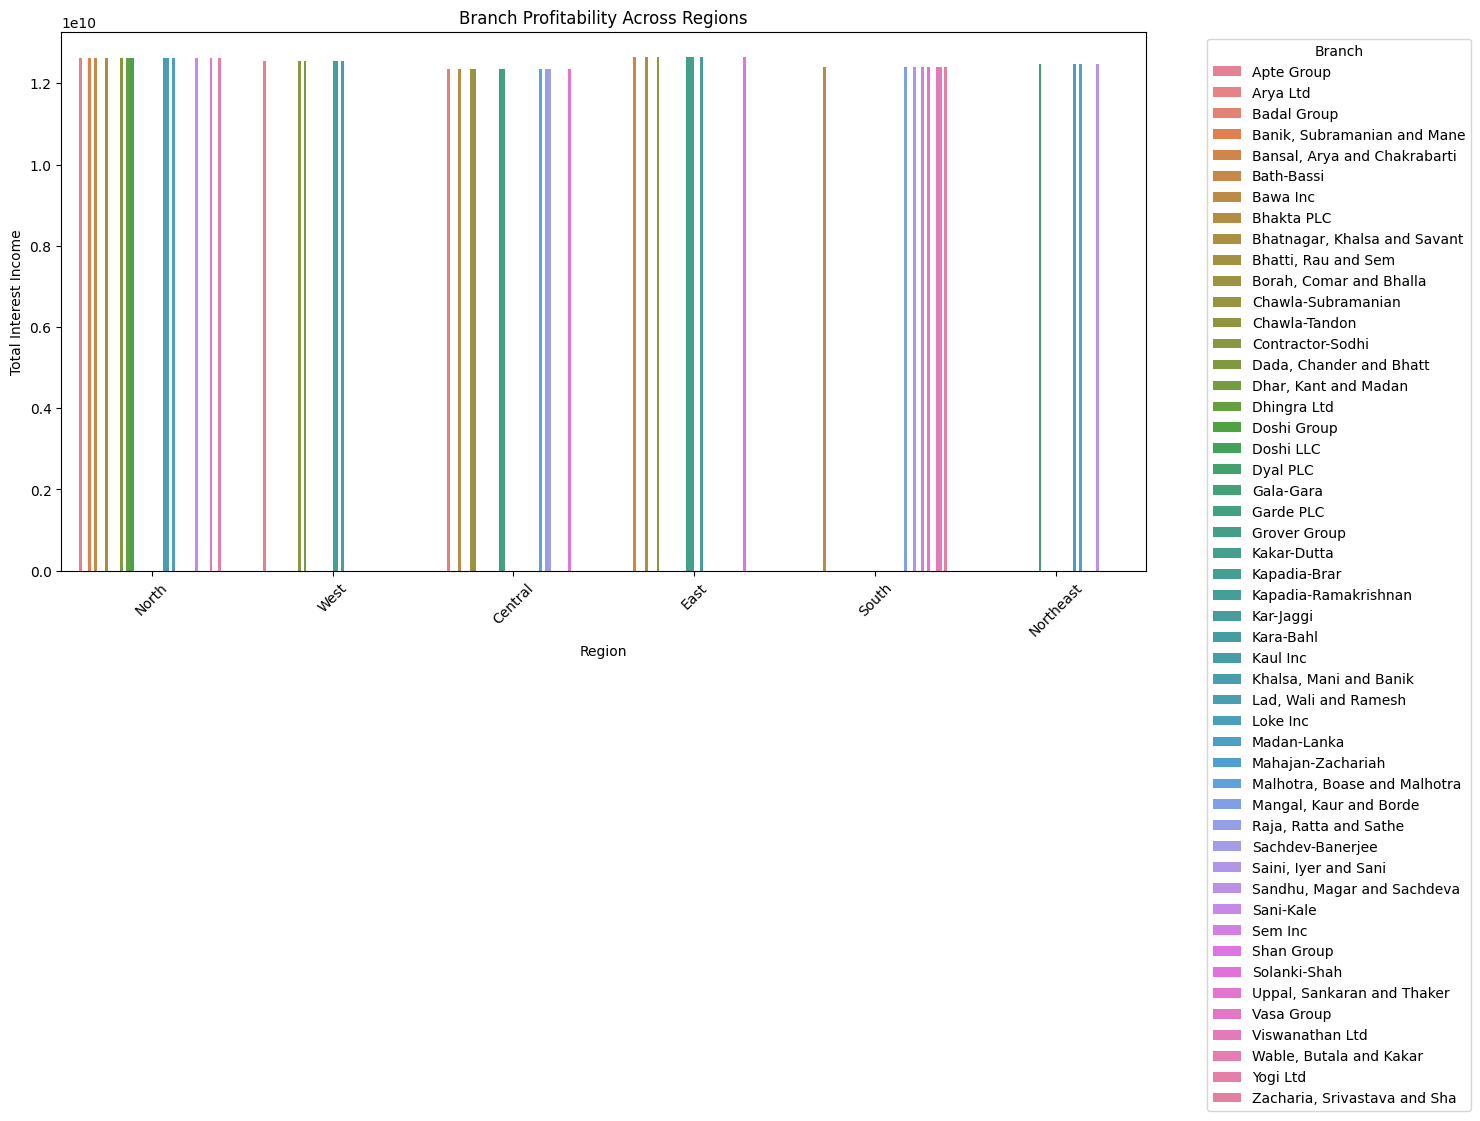

In [141]:
# Compare profitability metrics for branches across regions
loan_branch_profit = loan_app_interest.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
loan_branch_profit = loan_branch_profit.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')

profit_by_branch = loan_branch_profit.groupby(['Branch_Name','Region'])['Interest_Income'].sum().reset_index()

plt.figure(figsize=(14,7))
sns.barplot(x='Region', y='Interest_Income', hue='Branch_Name', data=profit_by_branch)
plt.title("Branch Profitability Across Regions")
plt.xlabel("Region")
plt.ylabel("Total Interest Income")
plt.xticks(rotation=45)
plt.legend(title='Branch', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 13 Geospatial analysis

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\27709066.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Active_Loan_Count', data=active_loan_counts, palette='Blues')


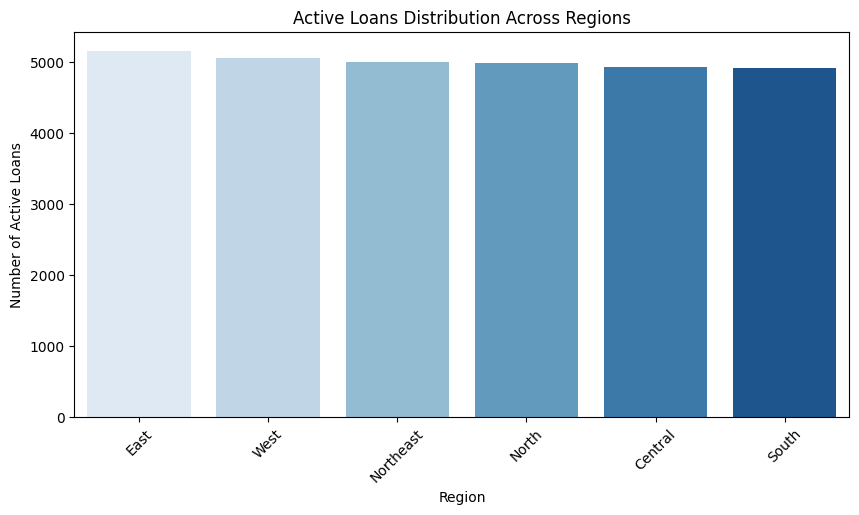

In [142]:
# Map distribution of active loans across regions
active_loans = loans[loans['Loan_Status'] == 'Active']
active_loans_region = active_loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')

active_loan_counts = active_loans_region['Region'].value_counts().reset_index()
active_loan_counts.columns = ['Region', 'Active_Loan_Count']

plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Active_Loan_Count', data=active_loan_counts, palette='Blues')
plt.title("Active Loans Distribution Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Active Loans")
plt.xticks(rotation=45)
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2310799485.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Default_Rate', data=default_rates, palette='Reds')


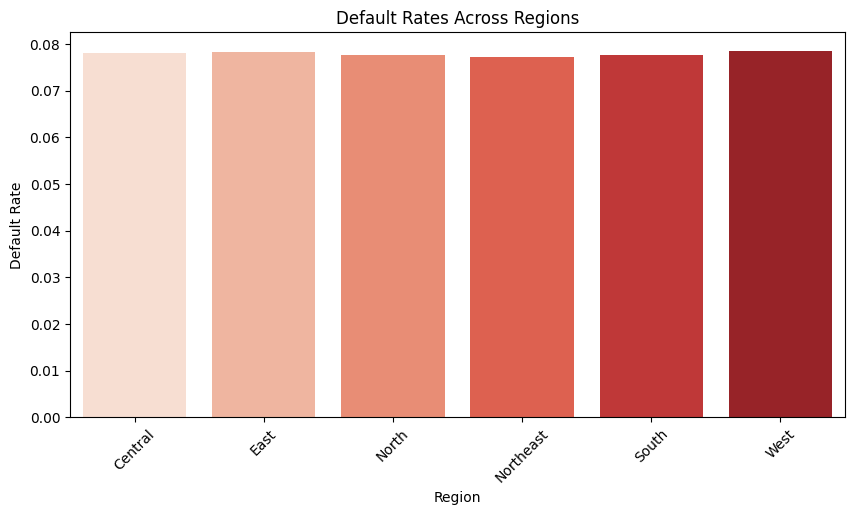

In [143]:
# Compare default rates across regions
# Calculate default rate = number of defaults / total loans in region
total_loans_region = loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
total_loans_count = total_loans_region.groupby('Region')['Loan_ID'].count().reset_index(name='Total_Loans')

defaults_region = defaults.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
defaults_count = defaults_region.groupby('Region')['Default_ID'].count().reset_index(name='Defaults')

default_rates = total_loans_count.merge(defaults_count, on='Region', how='left')
default_rates['Defaults'] = default_rates['Defaults'].fillna(0)
default_rates['Default_Rate'] = default_rates['Defaults'] / default_rates['Total_Loans']

plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Default_Rate', data=default_rates, palette='Reds')
plt.title("Default Rates Across Regions")
plt.xlabel("Region")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

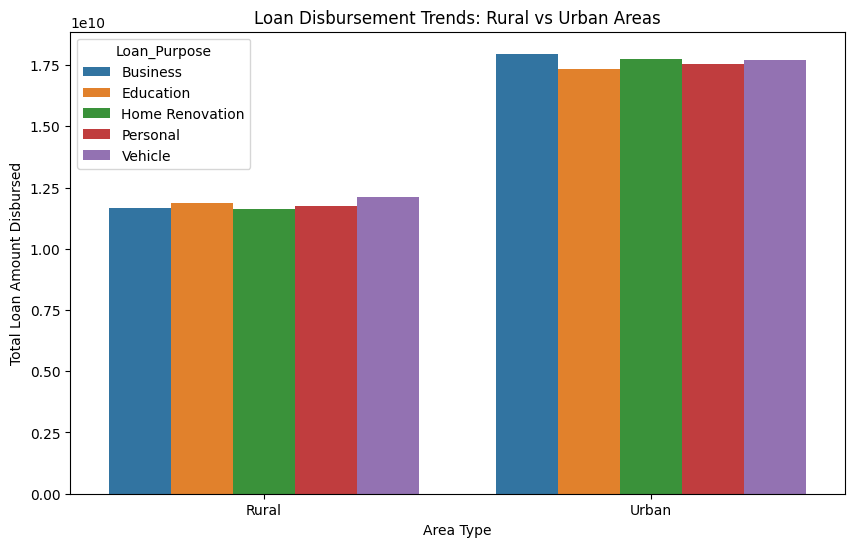

In [144]:
# Visualize loan disbursement trends for rural vs urban areas
# Assuming 'Region' column can be classified as rural or urban in a mapping dictionary
# You can define your own mapping below based on your data knowledge
rural_urban_map = {
    # Example mapping (replace with actual)
    'North': 'Urban',
    'South': 'Rural',
    'East': 'Urban',
    'West': 'Rural',
    'Central': 'Urban'
}

loan_app_region = loans.merge(applications[['Loan_ID','Loan_Purpose']], on='Loan_ID', how='left')
loan_app_region = loan_app_region.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
loan_app_region['Area_Type'] = loan_app_region['Region'].map(rural_urban_map)

disbursement_area = loan_app_region.groupby(['Area_Type','Loan_Purpose'])['Loan_Amount'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Area_Type', y='Loan_Amount', hue='Loan_Purpose', data=disbursement_area)
plt.title("Loan Disbursement Trends: Rural vs Urban Areas")
plt.xlabel("Area Type")
plt.ylabel("Total Loan Amount Disbursed")
plt.show()

#### 14 Default trends

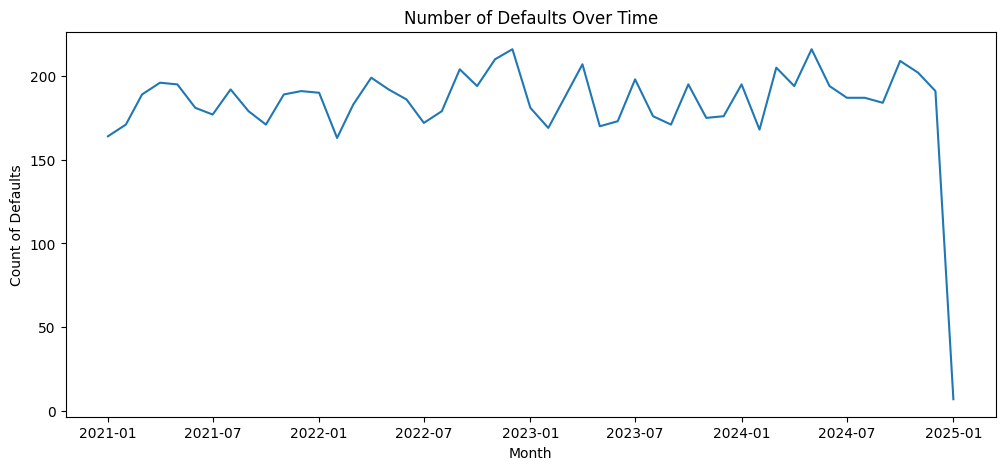

In [145]:
# Number of defaults over time (monthly)
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])
defaults['Default_Month'] = defaults['Default_Date'].dt.to_period('M')

defaults_over_time = defaults.groupby('Default_Month').size().reset_index(name='Default_Count')

plt.figure(figsize=(12,5))
defaults_over_time['Default_Month'] = defaults_over_time['Default_Month'].dt.to_timestamp()
sns.lineplot(x='Default_Month', y='Default_Count', data=defaults_over_time)
plt.title("Number of Defaults Over Time")
plt.xlabel("Month")
plt.ylabel("Count of Defaults")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\3755909684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Default_Amount', y='Loan_Purpose', data=avg_default_amount.sort_values('Default_Amount', ascending=False), palette='Oranges')


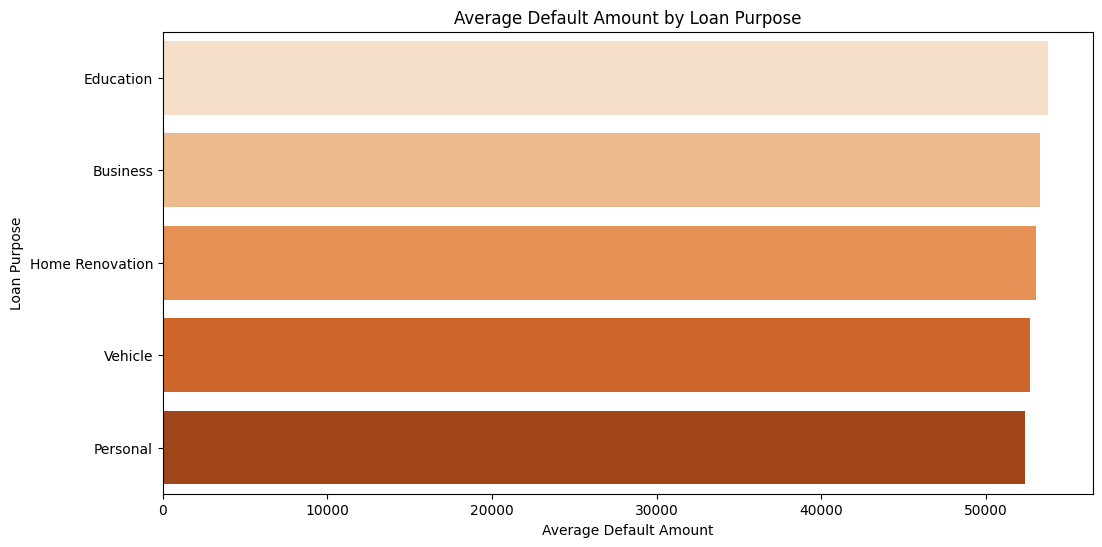

In [146]:
# Average default amount by loan purpose
defaults_loan = defaults.merge(applications[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='left')

avg_default_amount = defaults_loan.groupby('Loan_Purpose')['Default_Amount'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Default_Amount', y='Loan_Purpose', data=avg_default_amount.sort_values('Default_Amount', ascending=False), palette='Oranges')
plt.title("Average Default Amount by Loan Purpose")
plt.xlabel("Average Default Amount")
plt.ylabel("Loan Purpose")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1242207123.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_customers_inc = customers.groupby('Income_Category')['Customer_ID'].count().reset_index(name='Total_Customers')
C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1242207123.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defaults_count_inc = defaults_inc.groupby('Income_Category')['Default_ID'].count().reset_index(name='Defaults')
C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1242207123.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

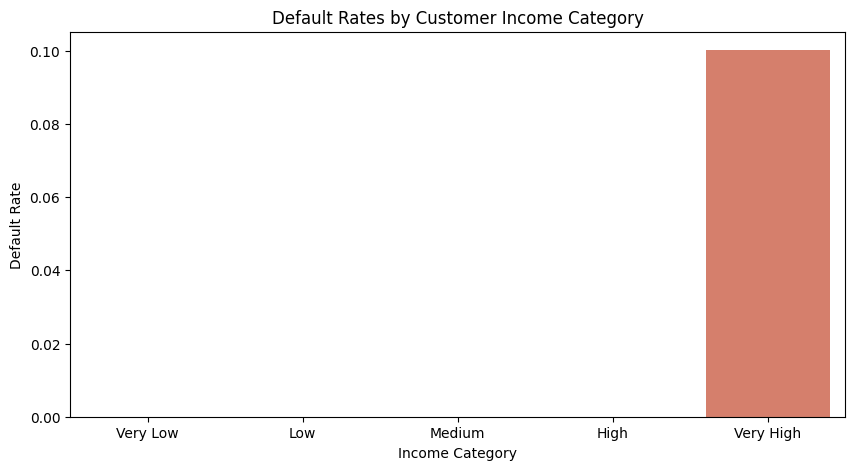

In [147]:
# Compare default rates across customer income categories
# Create income categories
bins = [0, 30000, 60000, 90000, 120000, 1e10]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

customers['Income_Category'] = pd.cut(customers['Annual_Income'], bins=bins, labels=labels, right=False)

# Total customers per income category
total_customers_inc = customers.groupby('Income_Category')['Customer_ID'].count().reset_index(name='Total_Customers')

# Defaults per income category
defaults_inc = defaults.merge(customers[['Customer_ID','Income_Category']], on='Customer_ID', how='left')
defaults_count_inc = defaults_inc.groupby('Income_Category')['Default_ID'].count().reset_index(name='Defaults')

# Merge and calculate default rate
default_rate_income = total_customers_inc.merge(defaults_count_inc, on='Income_Category', how='left')
default_rate_income['Defaults'] = default_rate_income['Defaults'].fillna(0)
default_rate_income['Default_Rate'] = default_rate_income['Defaults'] / default_rate_income['Total_Customers']

plt.figure(figsize=(10,5))
sns.barplot(x='Income_Category', y='Default_Rate', data=default_rate_income, palette='coolwarm')
plt.title("Default Rates by Customer Income Category")
plt.xlabel("Income Category")
plt.ylabel("Default Rate")
plt.show()

#### 15 Branch Efficiency

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1192549293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Disbursement_Time_Days', y='Branch_Name', data=branch_disbursement_time.sort_values('Disbursement_Time_Days'), palette='cool')


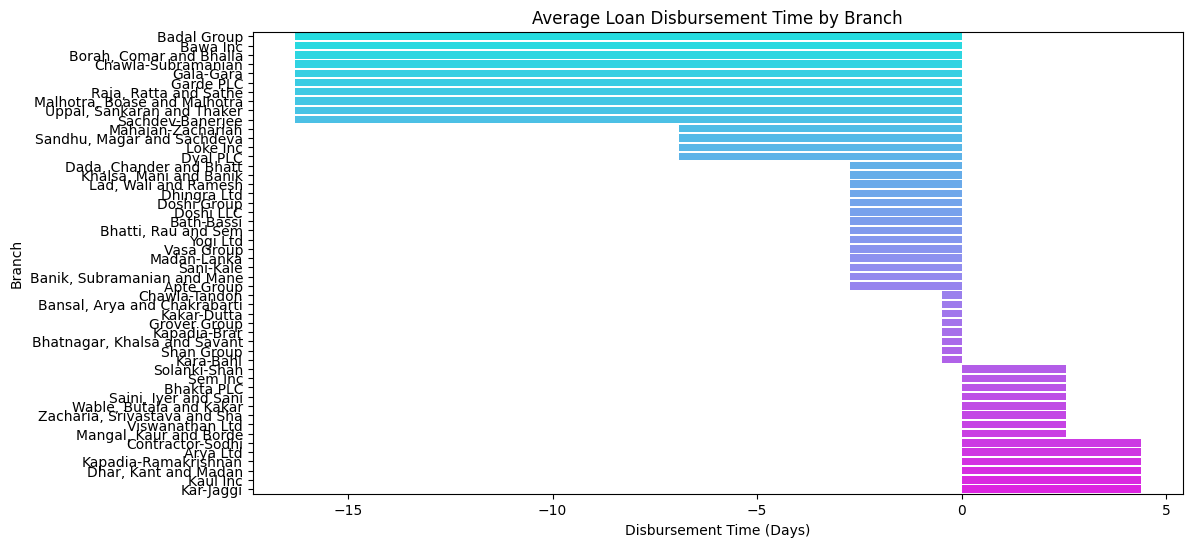

In [148]:
# Calculate average loan disbursement time for each branch
# Time from Approval_Date to Disbursal_Date (assuming Approval_Date as loan approval, Disbursal_Date as disbursement)
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'])
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])

app_loan = applications.merge(loans[['Loan_ID', 'Disbursal_Date']], on='Loan_ID', how='left')
app_loan['Disbursement_Time_Days'] = (app_loan['Disbursal_Date'] - app_loan['Approval_Date']).dt.days

# Merge with customers and branches for branch info
app_loan = app_loan.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
app_loan = app_loan.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')

branch_disbursement_time = app_loan.groupby('Branch_Name')['Disbursement_Time_Days'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Disbursement_Time_Days', y='Branch_Name', data=branch_disbursement_time.sort_values('Disbursement_Time_Days'), palette='cool')
plt.title("Average Loan Disbursement Time by Branch")
plt.xlabel("Disbursement Time (Days)")
plt.ylabel("Branch")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1201271157.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rejected_Applications', y='Branch_Name', data=rejected_counts.sort_values('Rejected_Applications', ascending=False), palette='Reds')


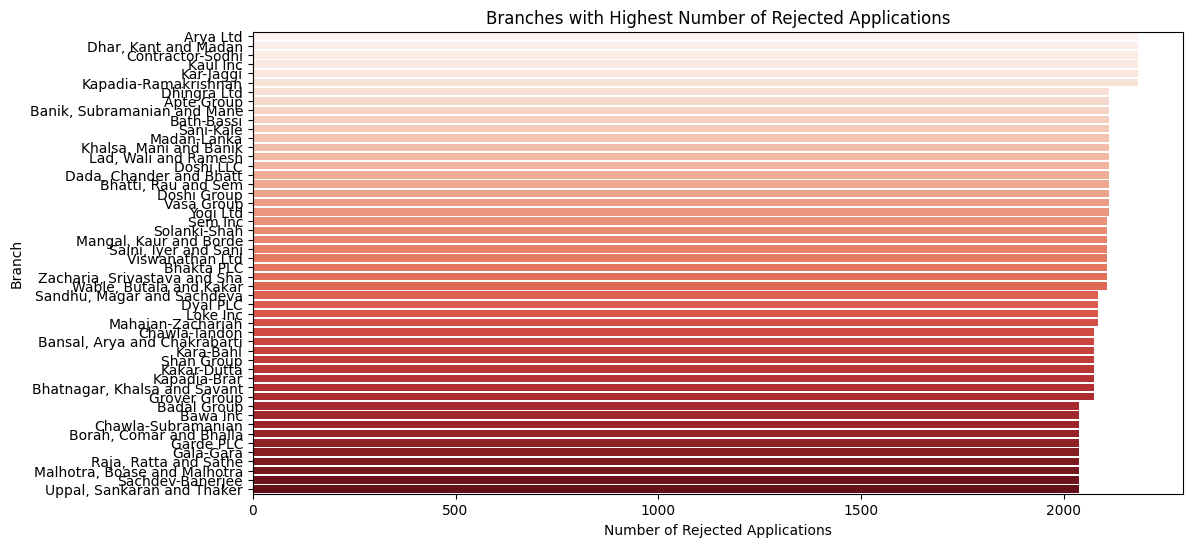

In [149]:
# Identify branches with the highest number of rejected applications
rejected_apps = applications[applications['Approval_Status'] == 'Rejected']
branch_rejected = rejected_apps.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
branch_rejected = branch_rejected.merge(branches[['Region','Branch_ID','Branch_Name']], on='Region', how='left')

rejected_counts = branch_rejected.groupby('Branch_Name').size().reset_index(name='Rejected_Applications')

plt.figure(figsize=(12,6))
sns.barplot(x='Rejected_Applications', y='Branch_Name', data=rejected_counts.sort_values('Rejected_Applications', ascending=False), palette='Reds')
plt.title("Branches with Highest Number of Rejected Applications")
plt.xlabel("Number of Rejected Applications")
plt.ylabel("Branch")
plt.show()

#### 16 time series analysis

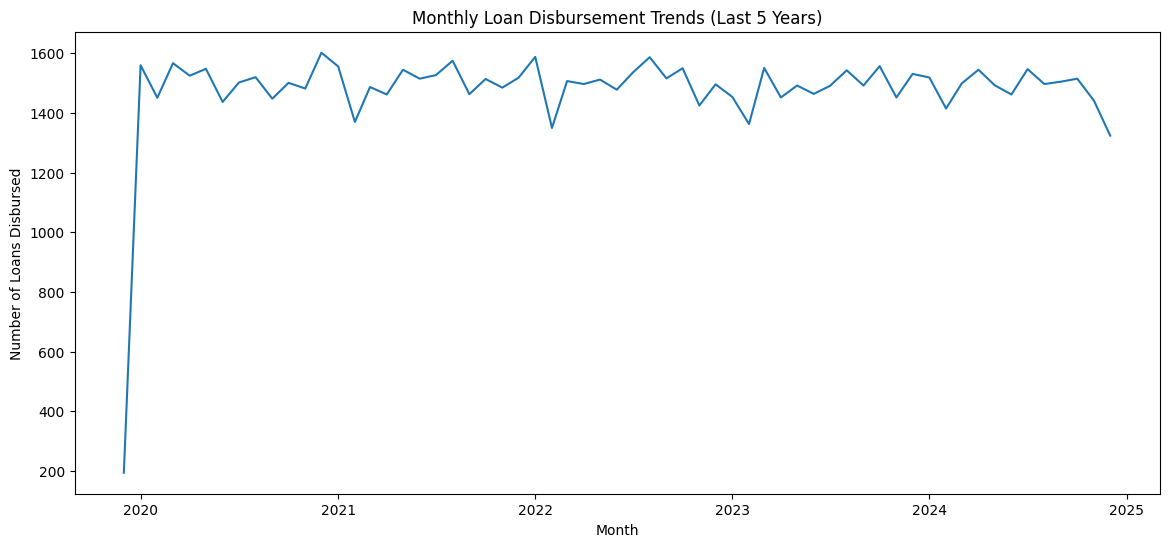

In [150]:
# Analyze monthly loan disbursement trends over the last 5 years
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])
loans['Disbursal_Month'] = loans['Disbursal_Date'].dt.to_period('M')

recent_loans = loans[loans['Disbursal_Date'] >= (loans['Disbursal_Date'].max() - pd.DateOffset(years=5))]

disbursement_monthly = recent_loans.groupby('Disbursal_Month').size().reset_index(name='Loan_Count')
disbursement_monthly['Disbursal_Month'] = disbursement_monthly['Disbursal_Month'].dt.to_timestamp()

plt.figure(figsize=(14,6))
sns.lineplot(x='Disbursal_Month', y='Loan_Count', data=disbursement_monthly)
plt.title("Monthly Loan Disbursement Trends (Last 5 Years)")
plt.xlabel("Month")
plt.ylabel("Number of Loans Disbursed")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\298437656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Application_Month', y='Application_Count', data=monthly_applications, palette='mako')


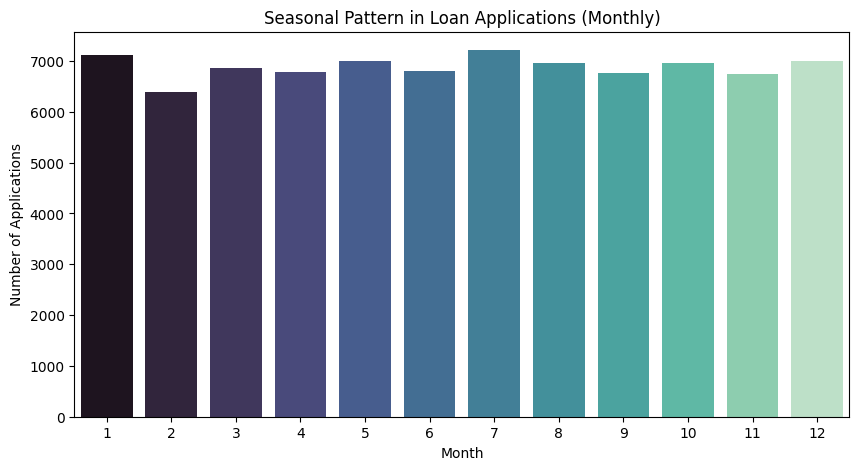

In [151]:
# Identify seasonal patterns in loan applications
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])
applications['Application_Month'] = applications['Application_Date'].dt.month

monthly_applications = applications.groupby('Application_Month').size().reset_index(name='Application_Count')

plt.figure(figsize=(10,5))
sns.barplot(x='Application_Month', y='Application_Count', data=monthly_applications, palette='mako')
plt.title("Seasonal Pattern in Loan Applications (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

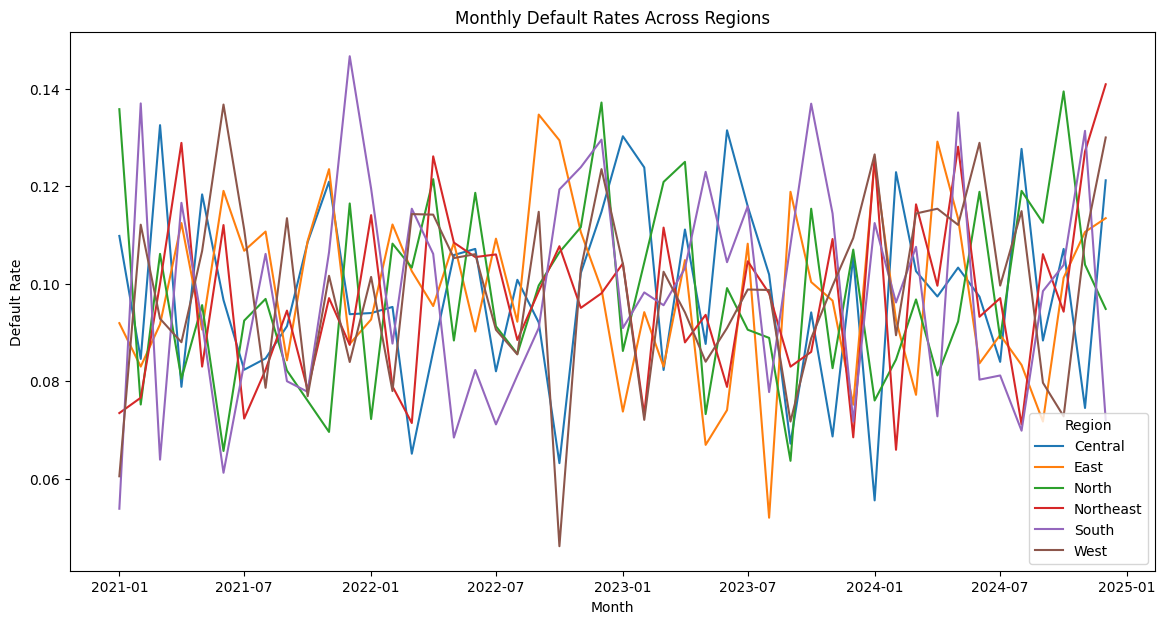

In [152]:
# Compare monthly default rates across regions
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])
defaults['Default_Month'] = defaults['Default_Date'].dt.to_period('M')

defaults_region = defaults.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')
total_loans_region = loans.merge(customers[['Customer_ID','Region']], on='Customer_ID', how='left')

# Defaults count by month and region
defaults_monthly_region = defaults_region.groupby(['Default_Month','Region']).size().reset_index(name='Defaults')

# Total loans count by month and region (approximate by disbursal month)
total_loans_region['Disbursal_Month'] = pd.to_datetime(total_loans_region['Disbursal_Date']).dt.to_period('M')
loans_monthly_region = total_loans_region.groupby(['Disbursal_Month','Region']).size().reset_index(name='Total_Loans')

# Merge on month and region for rate calculation
merged_defaults = defaults_monthly_region.merge(loans_monthly_region, left_on=['Default_Month','Region'], right_on=['Disbursal_Month','Region'], how='left')
merged_defaults['Default_Rate'] = merged_defaults['Defaults'] / merged_defaults['Total_Loans']

# Convert period to timestamp
merged_defaults['Default_Month'] = merged_defaults['Default_Month'].dt.to_timestamp()

plt.figure(figsize=(14,7))
sns.lineplot(data=merged_defaults, x='Default_Month', y='Default_Rate', hue='Region')
plt.title("Monthly Default Rates Across Regions")
plt.xlabel("Month")
plt.ylabel("Default Rate")
plt.legend(title='Region')
plt.show()

#### 17 Customer behaviour analysis

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\1356995750.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Repayment_Behavior', data=customers_behavior, palette='pastel')


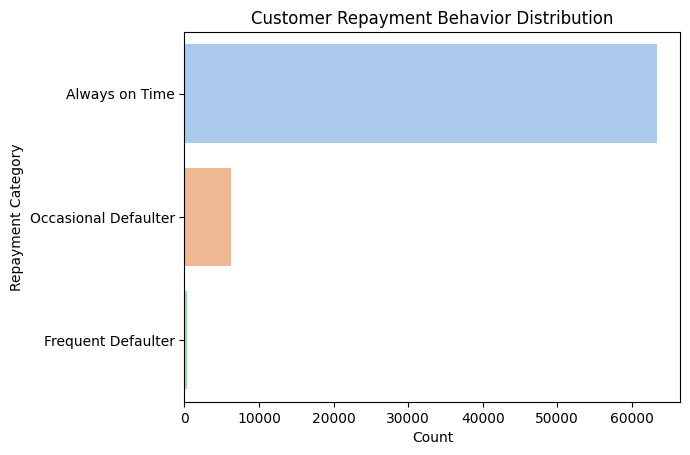

In [153]:
# Categorize customers based on repayment behavior
# Define: always on time, occasional defaulters, frequent defaulters
# Count defaults per customer
customer_defaults = defaults.groupby('Customer_ID').size().reset_index(name='Default_Count')

def repayment_category(row):
    if row['Default_Count'] == 0:
        return 'Always on Time'
    elif row['Default_Count'] <= 1:
        return 'Occasional Defaulter'
    else:
        return 'Frequent Defaulter'

customer_defaults['Repayment_Behavior'] = customer_defaults.apply(repayment_category, axis=1)

# Merge back with customers
customers_behavior = customers.merge(customer_defaults[['Customer_ID','Repayment_Behavior']], on='Customer_ID', how='left')
customers_behavior['Repayment_Behavior'] = customers_behavior['Repayment_Behavior'].fillna('Always on Time')

sns.countplot(y='Repayment_Behavior', data=customers_behavior, palette='pastel')
plt.title("Customer Repayment Behavior Distribution")
plt.xlabel("Count")
plt.ylabel("Repayment Category")
plt.show()

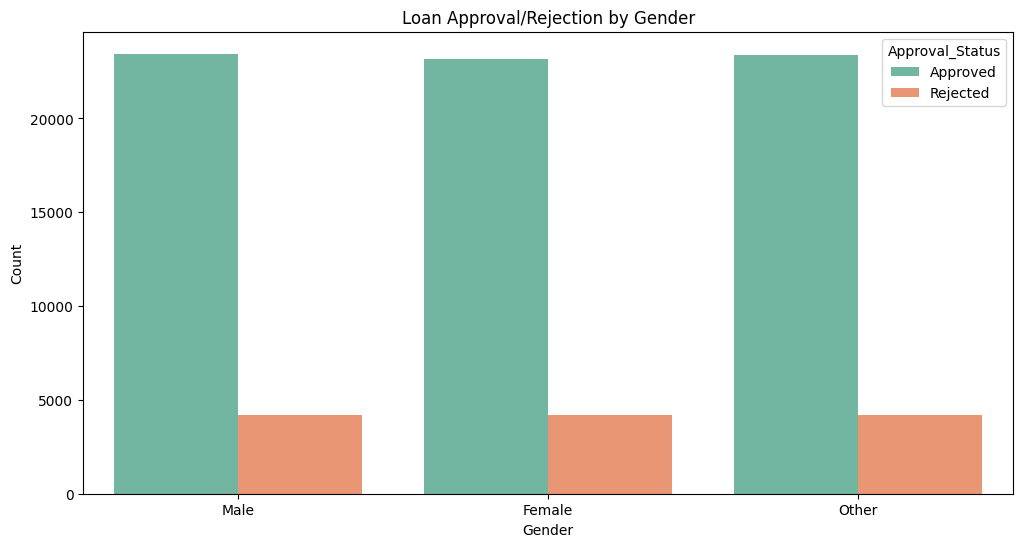

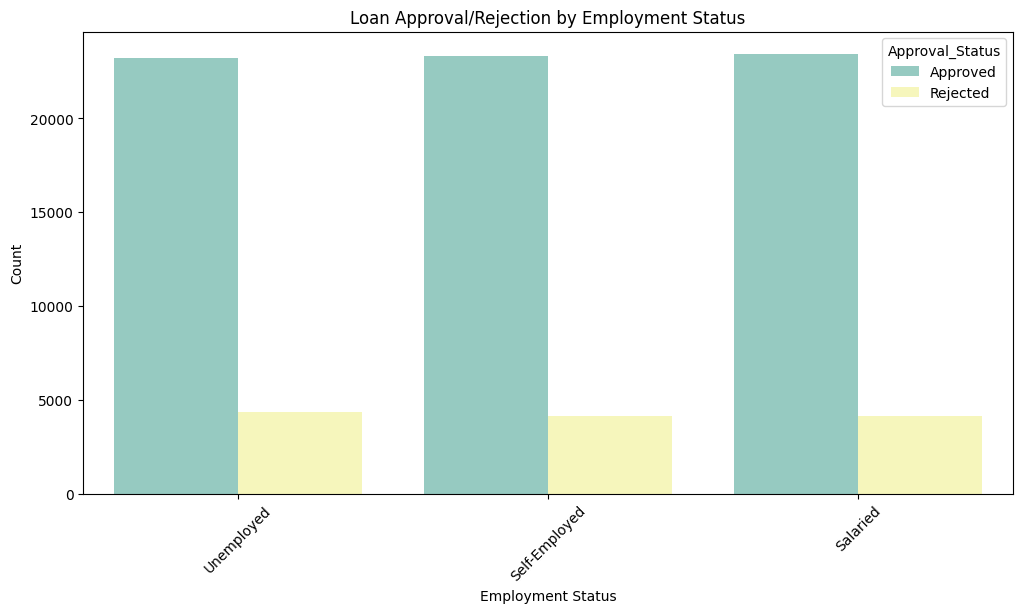

In [154]:
# Analyze patterns in loan approval/rejection by customer demographics
approval_demo = applications.merge(customers[['Customer_ID','Gender','Employment_Status','Region']], on='Customer_ID', how='left')

plt.figure(figsize=(12,6))
sns.countplot(x='Gender', hue='Approval_Status', data=approval_demo, palette='Set2')
plt.title("Loan Approval/Rejection by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x='Employment_Status', hue='Approval_Status', data=approval_demo, palette='Set3')
plt.title("Loan Approval/Rejection by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [155]:
# Identify high-value customers with consistent repayment
high_value_customers = customers_behavior[(customers_behavior['Annual_Income'] >= 90000) & 
                                          (customers_behavior['Repayment_Behavior'] == 'Always on Time')]

high_value_customers_summary = high_value_customers[['Customer_ID','Full_Name','Annual_Income','Credit_Score']]
high_value_customers_summary.head()

,Customer_ID,Full_Name,Annual_Income,Credit_Score
0,C000001,Shayak Kumar,886810,433
1,C000002,Divij Ghosh,396746,418
2,C000003,Rhea Bhargava,1118591,736
3,C000004,Indrans Walia,524075,353
4,C000005,Saanvi Chad,1219355,735


#### Risk assessment

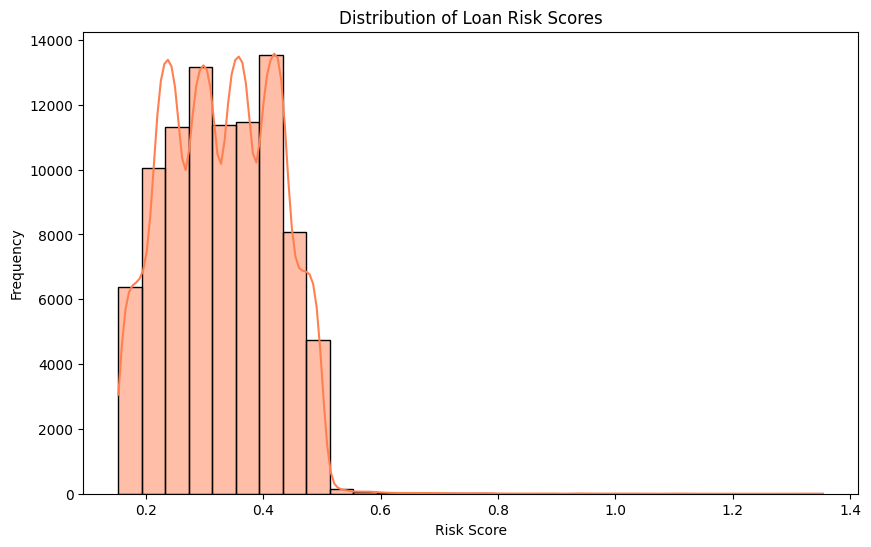

In [156]:
# Develop a risk matrix for loan products based on Default_Amount, Loan_Term, and Interest_Rate
loans_defaults = loans.merge(defaults[['Loan_ID','Default_Amount']], on='Loan_ID', how='left')
loans_defaults['Default_Amount'] = loans_defaults['Default_Amount'].fillna(0)

# Define risk score: higher default, longer term, higher interest = higher risk
loans_defaults['Risk_Score'] = (loans_defaults['Default_Amount']/loans_defaults['Loan_Amount']) * 0.5 + \
                                (loans_defaults['Loan_Term']/loans_defaults['Loan_Term'].max()) * 0.3 + \
                                (loans_defaults['Interest_Rate']/loans_defaults['Interest_Rate'].max()) * 0.2

plt.figure(figsize=(10,6))
sns.histplot(loans_defaults['Risk_Score'], bins=30, kde=True, color='coral')
plt.title("Distribution of Loan Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

C:\Users\AkashAatha\AppData\Local\Temp\ipykernel_10128\2701270376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk_Score', y='Loan_Purpose', data=risk_by_loan_type, palette='Reds')


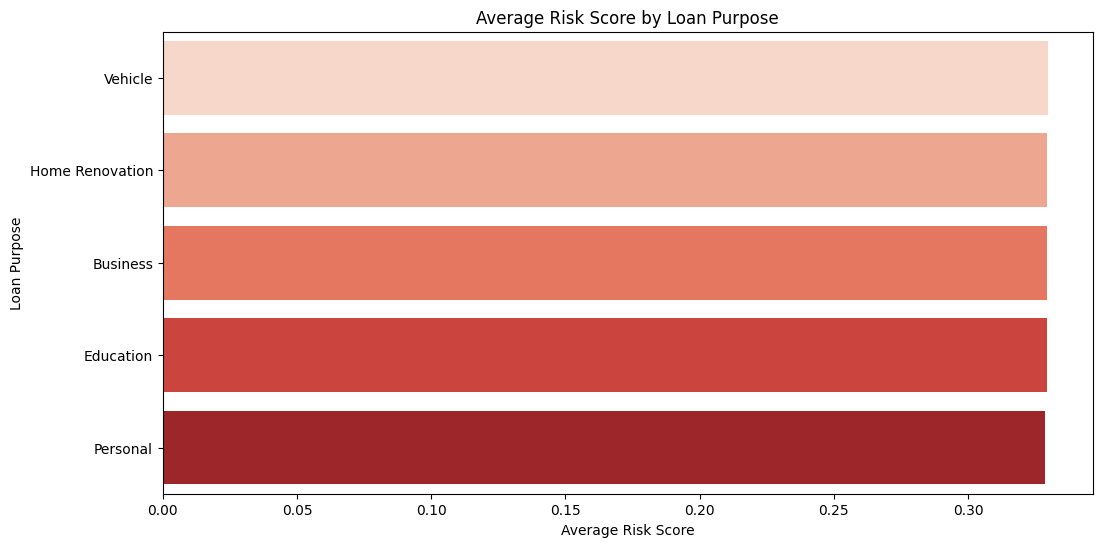

In [157]:
# Rank loan types by risk level
applications_loans = applications.merge(loans_defaults[['Loan_ID','Risk_Score']], on='Loan_ID', how='left')
risk_by_loan_type = applications_loans.groupby('Loan_Purpose')['Risk_Score'].mean().reset_index().sort_values('Risk_Score', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Risk_Score', y='Loan_Purpose', data=risk_by_loan_type, palette='Reds')
plt.title("Average Risk Score by Loan Purpose")
plt.xlabel("Average Risk Score")
plt.ylabel("Loan Purpose")
plt.show()

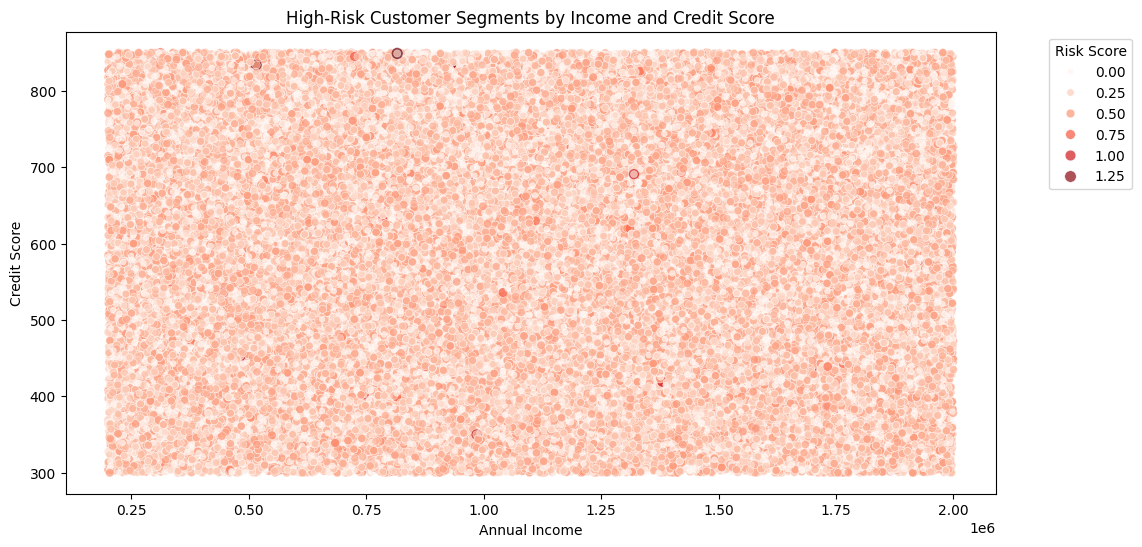

In [159]:
# Analyze high-risk customer segments by credit score and income
customers_risk = customers_behavior.merge(loans_defaults[['Customer_ID','Risk_Score']], on='Customer_ID', how='left')
customers_risk['Risk_Score'] = customers_risk['Risk_Score'].fillna(0)

plt.figure(figsize=(12,6))
sns.scatterplot(x='Annual_Income', y='Credit_Score', size='Risk_Score', hue='Risk_Score', data=customers_risk, palette='Reds', alpha=0.7)
plt.title("High-Risk Customer Segments by Income and Credit Score")
plt.xlabel("Annual Income")
plt.ylabel("Credit Score")
plt.legend(title='Risk Score', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

#### 19 Time to default analysis